# BIT 2118 – Scientific Computing: Tasks 2 to 20

**Student:** Kamunyu Raphael · **Reg. no:** BSCCS/2024/45844

Each task has a short description and three code parts: the original program, a changed input, and a related real-world case. Run the cells from top to bottom (**Kernel → Restart & Run All**). Timings in Tasks 3 and 7 vary by computer.

## Task 1 – Prerequisite

*Data Science Essentials with Python* is a self-paced course with no program. Complete it before the presentation tasks.

In [1]:
import warnings
warnings.filterwarnings('ignore')
%matplotlib inline

---
## Task 2 – NumPy Arrays and Numerical Computation

Store 24 hourly temperatures in an array, then compute the mean, minimum and maximum and convert °C to °F in one vectorized step.

In [2]:
import numpy as np

**Part 1 – Original program** (from the brief, with extra checks).

In [3]:
print("=== PART 1: Original - weather station ===")
temperatures_c = np.array([
    18.5, 18.0, 17.8, 17.5, 17.9, 19.0,
    21.5, 23.8, 25.6, 27.1, 28.3, 29.0,
    29.4, 29.1, 28.5, 27.6, 26.2, 24.8,
    23.4, 22.1, 21.0, 20.2, 19.6, 19.0
])
mean_temp, min_temp, max_temp = np.mean(temperatures_c), np.min(temperatures_c), np.max(temperatures_c)
temperatures_f = 1.8 * temperatures_c + 32
print(f"Daily mean temperature: {mean_temp:.2f} C")
print(f"Minimum temperature: {min_temp:.2f} C")
print(f"Maximum temperature: {max_temp:.2f} C")
print("First six Fahrenheit readings:", temperatures_f[:6])

=== PART 1: Original - weather station ===
Daily mean temperature: 23.12 C
Minimum temperature: 17.50 C
Maximum temperature: 29.40 C
First six Fahrenheit readings: [65.3  64.4  64.04 63.5  64.22 66.2 ]


**Part 2 – Changed input:** one or more parameters are changed to see how the result responds.

In [4]:
print("\n=== PART 2: Changed input - midday (12:00) reading is a sensor spike (29.4 -> 45.0) ===")
spiked = temperatures_c.copy()
spiked[12] = 45.0
print(f"Mean: {spiked.mean():.2f} C (was {mean_temp:.2f})")
print(f"Max : {spiked.max():.2f} C (was {max_temp:.2f})")
print(f"Median: {np.median(spiked):.2f} C (was {np.median(temperatures_c):.2f})")


=== PART 2: Changed input - midday (12:00) reading is a sensor spike (29.4 -> 45.0) ===
Mean: 23.77 C (was 23.12)
Max : 45.00 C (was 29.40)
Median: 22.75 C (was 22.75)


**Part 3 – Related real-world case:** the program adapted to a different problem.

In [5]:
print("\n=== PART 3: Related case - greenhouse IoT, 24 hourly readings ===")
rng = np.random.default_rng(7)
hours = np.arange(24)
greenhouse_c = 24 + 6*np.sin((hours - 9) * np.pi / 12) + rng.normal(0, 0.4, 24)
alert_limit = 28.0
alerts = greenhouse_c > alert_limit
kelvin = greenhouse_c + 273.15
print(f"Mean {greenhouse_c.mean():.2f} C | min {greenhouse_c.min():.2f} C | max {greenhouse_c.max():.2f} C")
print(f"Hours above {alert_limit} C: {alerts.sum()} -> hours {hours[alerts]}")
print(f"Std deviation: {greenhouse_c.std(ddof=1):.2f} C")
print(f"Max in Kelvin: {kelvin.max():.2f} K")


=== PART 3: Related case - greenhouse IoT, 24 hourly readings ===


Mean 23.84 C | min 17.64 C | max 30.28 C
Hours above 28.0 C: 6 -> hours [12 13 14 15 16 17]
Std deviation: 4.29 C
Max in Kelvin: 303.43 K


---
## Task 3 – Mathematical Functions and Vectorization

Apply a calculation to a million values at once and compare a Python loop with a vectorized NumPy expression.

In [6]:
import numpy as np
import timeit

def compare(latency_ms):
    def loop_version():
        squared = []
        for value in latency_ms:
            seconds = value / 1000.0
            squared.append(seconds ** 2)
        return squared
    def vectorized_version():
        seconds = latency_ms / 1000.0
        return seconds ** 2
    loop_time = timeit.timeit(loop_version, number=1)
    vector_time = timeit.timeit(vectorized_version, number=3) / 3
    return loop_time, vector_time, vectorized_version()

**Part 1 – Original program** (from the brief, with extra checks).

In [7]:
print("=== PART 1: Original - 1,000,000 latency readings ===")
rng = np.random.default_rng(42)
latency_ms = rng.uniform(5, 250, 1_000_000)
loop_time, vector_time, result = compare(latency_ms)
print("First five squared latency values:", result[:5])
print(f"Loop time: {loop_time:.4f} s")
print(f"Vectorized time: {vector_time:.6f} s")
print(f"Approximate speed-up: {loop_time/vector_time:.1f}x")

=== PART 1: Original - 1,000,000 latency readings ===
First five squared latency values: [0.03787665 0.01266192 0.04637842 0.03092504 0.00078812]
Loop time: 0.6180 s
Vectorized time: 0.010444 s
Approximate speed-up: 59.2x


**Part 2 – Changed input:** one or more parameters are changed to see how the result responds.

In [8]:
print("\n=== PART 2: Changed input - N = 1,000 instead of 1,000,000 ===")
small = rng.uniform(5, 250, 1_000)
lt, vt, _ = compare(small)
print(f"Loop time: {lt:.6f} s | Vectorized: {vt:.8f} s | speed-up: {lt/vt:.1f}x")


=== PART 2: Changed input - N = 1,000 instead of 1,000,000 ===
Loop time: 0.001322 s | Vectorized: 0.00006880 s | speed-up: 19.2x


**Part 3 – Related real-world case:** the program adapted to a different problem.

In [9]:
print("\n=== PART 3: Related case - ADC samples to RMS voltage (2,000,000 samples) ===")
# 12-bit ADC (0-4095 counts) mapped to 0-3.3 V; remove DC offset then RMS
counts = rng.integers(0, 4096, 2_000_000)
def rms_loop():
    total = 0.0
    for c in counts:
        total += (c * 3.3 / 4095) ** 2
    return (total / len(counts)) ** 0.5
def rms_vec():
    volts = counts * 3.3 / 4095
    return np.sqrt(np.mean(volts ** 2))
t_loop = timeit.timeit(rms_loop, number=1)
t_vec = timeit.timeit(rms_vec, number=3) / 3
print(f"RMS (loop) = {rms_loop():.6f} V | RMS (vectorized) = {rms_vec():.6f} V")
print(f"Loop {t_loop:.3f} s | Vectorized {t_vec:.5f} s | speed-up {t_loop/t_vec:.0f}x")
x = np.linspace(0, 2*np.pi, 1_000_000)
print("Identity check max |sin^2+cos^2-1| =", np.max(np.abs(np.sin(x)**2 + np.cos(x)**2 - 1)))


=== PART 3: Related case - ADC samples to RMS voltage (2,000,000 samples) ===
RMS (loop) = 1.905799 V | RMS (vectorized) = 1.905799 V
Loop 14.095 s | Vectorized 0.03945 s | speed-up 357x
Identity check max |sin^2+cos^2-1| = 2.220446049250313e-16


---
## Task 4 – Floating-Point Arithmetic and Numerical Errors

Show why 0.1 + 0.2 ≠ 0.3, measure absolute and relative error, and compare an unstable formula with a stable one.

In [10]:
import math
import numpy as np

**Part 1 – Original program** (from the brief, with extra checks).

In [11]:
print("=== PART 1: Original ===")
calculated = 0.1 + 0.2
expected = 0.3
print("0.1 + 0.2 =", calculated)
print("Exact comparison:", calculated == expected)
print("Tolerance-based comparison:", np.isclose(calculated, expected))
true_value = np.sqrt(2)
approx_value = 1.414
absolute_error = abs(true_value - approx_value)
relative_error = absolute_error / abs(true_value)
print(f"Absolute error: {absolute_error:.8f}")
print(f"Relative error: {relative_error:.8%}")
for x in [1e-4, 1e-8, 1e-12]:
    direct = (np.sqrt(1 + x) - 1) / x
    stable = 1 / (np.sqrt(1 + x) + 1)
    print(f"x={x:.0e}: direct={direct:.12f}, stable={stable:.12f}")

=== PART 1: Original ===
0.1 + 0.2 = 0.30000000000000004
Exact comparison: False
Tolerance-based comparison: True
Absolute error: 0.00021356
Relative error: 0.01510114%
x=1e-04: direct=0.499987500624, stable=0.499987500625
x=1e-08: direct=0.499999996961, stable=0.499999998750
x=1e-12: direct=0.500044450291, stable=0.500000000000


**Part 2 – Changed input:** one or more parameters are changed to see how the result responds.

In [12]:
print("\n=== PART 2: Changed input - approximation 1.414 -> 1.41421 and extra x values ===")
for approx in (1.414, 1.4142, 1.41421):
    ae = abs(np.sqrt(2) - approx)
    print(f"approx={approx}: abs err={ae:.2e}, rel err={ae/np.sqrt(2):.4%}")
for x in [1e-14, 1e-16]:
    direct = (np.sqrt(1 + x) - 1) / x
    stable = 1 / (np.sqrt(1 + x) + 1)
    print(f"x={x:.0e}: direct={direct:.12f}, stable={stable:.12f}")


=== PART 2: Changed input - approximation 1.414 -> 1.41421 and extra x values ===
approx=1.414: abs err=2.14e-04, rel err=0.0151%
approx=1.4142: abs err=1.36e-05, rel err=0.0010%
approx=1.41421: abs err=3.56e-06, rel err=0.0003%
x=1e-14: direct=0.488498130835, stable=0.500000000000
x=1e-16: direct=0.000000000000, stable=0.500000000000


**Part 3 – Related real-world case:** the program adapted to a different problem.

In [13]:
print("\n=== PART 3: Related case - banking: adding 0.10 one million times ===")
naive = 0.0
for _ in range(1_000_000):
    naive += 0.10
exact_total = 100_000.0
print(f"Naive float sum   : {naive:.10f}")
print(f"math.fsum         : {math.fsum([0.10]*1_000_000):.10f}")
print(f"Expected          : {exact_total:.10f}")
print(f"Naive abs error   : {abs(naive-exact_total):.3e}")
print("Naive == expected :", naive == exact_total, "| np.isclose:", np.isclose(naive, exact_total))
from decimal import Decimal
print("Decimal sum       :", sum([Decimal('0.10')]*1_000_000))


=== PART 3: Related case - banking: adding 0.10 one million times ===
Naive float sum   : 100000.0000013329
math.fsum         : 100000.0000000000
Expected          : 100000.0000000000
Naive abs error   : 1.333e-06
Naive == expected : False | np.isclose: True
Decimal sum       : 100000.00


---
## Task 5 – Matrix Algebra and Matrix Operations

Rotate and scale 2-D points with matrix multiplication and use the determinant and inverse.

In [14]:
import numpy as np
import matplotlib.pyplot as plt

def transform(points, angle_deg, sx, sy):
    a = np.deg2rad(angle_deg)
    rotation = np.array([[np.cos(a), -np.sin(a)], [np.sin(a), np.cos(a)]])
    scale = np.array([[sx, 0.0], [0.0, sy]])
    T = rotation @ scale
    return T, points @ T.T

points = np.array([[0.0, 0.0], [1.0, 0.0], [1.0, 1.0], [0.0, 1.0]])

**Part 1 – Original program** (from the brief, with extra checks).

In [15]:
print("=== PART 1: Original - rotate 45 deg, scale (2, 1.5) ===")
T, out = transform(points, 45, 2.0, 1.5)
print("Original points:\n", points)
print("Transformation matrix:\n", T)
print("Transformed points:\n", out)
print("Determinant:", np.linalg.det(T))

=== PART 1: Original - rotate 45 deg, scale (2, 1.5) ===
Original points:
 [[0. 0.]
 [1. 0.]
 [1. 1.]
 [0. 1.]]
Transformation matrix:
 [[ 1.41421356 -1.06066017]
 [ 1.41421356  1.06066017]]
Transformed points:
 [[ 0.          0.        ]
 [ 1.41421356  1.41421356]
 [ 0.35355339  2.47487373]
 [-1.06066017  1.06066017]]
Determinant: 3.000000000000001


**Part 2 – Changed input:** one or more parameters are changed to see how the result responds.

In [16]:
print("\n=== PART 2: Changed input - rotate 90 deg, scale (1, 1) then (2, 0) ===")
T2, out2 = transform(points, 90, 1.0, 1.0)
print("90 deg rotation only:\n", np.round(out2, 6), "\nDeterminant:", round(np.linalg.det(T2), 6))
T3, out3 = transform(points, 45, 2.0, 0.0)
print("Scale y by 0 (singular):\n", np.round(out3, 4), "\nDeterminant:", round(np.linalg.det(T3), 12))


=== PART 2: Changed input - rotate 90 deg, scale (1, 1) then (2, 0) ===
90 deg rotation only:
 [[ 0.  0.]
 [ 0.  1.]
 [-1.  1.]
 [-1.  0.]] 
Determinant: 1.0
Scale y by 0 (singular):
 [[0.     0.    ]
 [1.4142 1.4142]
 [1.4142 1.4142]
 [0.     0.    ]] 
Determinant: 0.0


**Part 3 – Related real-world case:** the program adapted to a different problem.


=== PART 3: Related case - reflect a triangle in the y-axis then shear ===
Combined matrix M = shear @ reflect:
 [[-1.   0.5]
 [ 0.   1. ]]
New triangle:
 [[ 0.   0. ]
 [-4.   0. ]
 [-0.5  3. ]]
det(M) = -1.0 (negative => orientation flipped)
Recovered with inverse:
 [[0. 0.]
 [4. 0.]
 [2. 3.]]
AA^-1 = I check: True


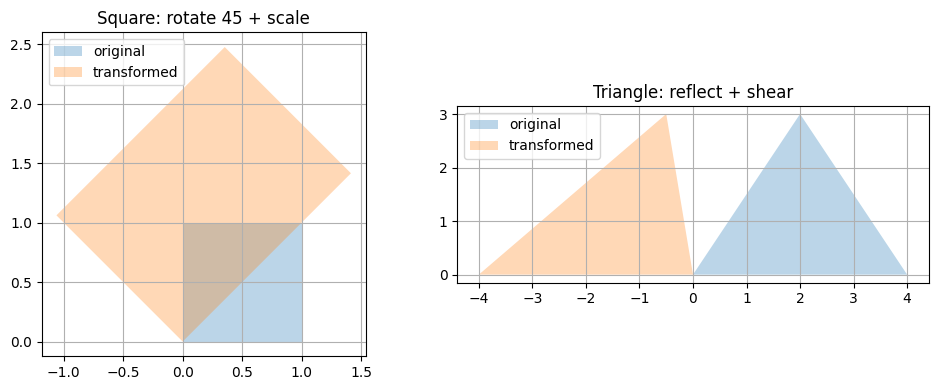

In [17]:
print("\n=== PART 3: Related case - reflect a triangle in the y-axis then shear ===")
tri = np.array([[0.0, 0.0], [4.0, 0.0], [2.0, 3.0]])
reflect_y = np.array([[-1.0, 0.0], [0.0, 1.0]])
shear = np.array([[1.0, 0.5], [0.0, 1.0]])
M = shear @ reflect_y
new_tri = tri @ M.T
print("Combined matrix M = shear @ reflect:\n", M)
print("New triangle:\n", new_tri)
print("det(M) =", np.linalg.det(M), "(negative => orientation flipped)")
back = new_tri @ np.linalg.inv(M).T
print("Recovered with inverse:\n", back)
print("AA^-1 = I check:", np.allclose(M @ np.linalg.inv(M), np.eye(2)))

fig, ax = plt.subplots(1, 2, figsize=(10, 4))
for a_, pts, new, title in ((ax[0], points, out, "Square: rotate 45 + scale"), (ax[1], tri, new_tri, "Triangle: reflect + shear")):
    a_.fill(*np.vstack([pts, pts[:1]]).T, alpha=0.3, label="original")
    a_.fill(*np.vstack([new, new[:1]]).T, alpha=0.3, label="transformed")
    a_.set_aspect("equal"); a_.grid(True); a_.legend(); a_.set_title(title)
plt.tight_layout(); plt.show()

---
## Task 6 – Solution of Systems of Linear Equations

Solve Ax = b to find how many servers of each type are active, and check the residual.

In [18]:
import numpy as np

**Part 1 – Original program** (from the brief, with extra checks).

In [19]:
print("=== PART 1: Original - servers ===")
A = np.array([[4.0, 2.0], [8.0, 12.0]])
b = np.array([20.0, 72.0])
solution = np.linalg.solve(A, b)
residual = b - A @ solution
print(f"Type A servers: {solution[0]:.0f}")
print(f"Type B servers: {solution[1]:.0f}")
print("Verification A @ solution:", A @ solution)
print("Residual:", residual)
print("Residual norm:", np.linalg.norm(residual))
print("det(A) =", np.linalg.det(A), "| cond(A) =", round(np.linalg.cond(A), 2))

=== PART 1: Original - servers ===
Type A servers: 3
Type B servers: 4
Verification A @ solution: [20. 72.]
Residual: [0. 0.]
Residual norm: 0.0
det(A) = 31.999999999999986 | cond(A) = 6.98


**Part 2 – Changed input:** one or more parameters are changed to see how the result responds.

In [20]:
print("\n=== PART 2: Changed input - totals become 28 CPU and 96 GB ===")
b2 = np.array([28.0, 96.0])
s2 = np.linalg.solve(A, b2)
print("Solution (A, B):", s2, "| residual norm:", np.linalg.norm(b2 - A @ s2))
print("\nChanged to an inconsistent/near-singular system (row 2 = 2 x row 1 + tiny change):")
A3 = np.array([[4.0, 2.0], [8.0, 4.0001]])
b3 = np.array([20.0, 40.0])
print("cond(A3) =", f"{np.linalg.cond(A3):.3e}", "| solution:", np.linalg.solve(A3, b3))
b3b = np.array([20.0, 40.001])
print("Tiny change in b ->", np.linalg.solve(A3, b3b))


=== PART 2: Changed input - totals become 28 CPU and 96 GB ===
Solution (A, B): [4.5 5. ] | residual norm: 0.0

Changed to an inconsistent/near-singular system (row 2 = 2 x row 1 + tiny change):
cond(A3) = 2.500e+05 | solution: [ 5. -0.]
Tiny change in b -> [ 0. 10.]


**Part 3 – Related real-world case:** the program adapted to a different problem.

In [21]:
print("\n=== PART 3: Related case - mesh-current analysis of a 3-loop circuit ===")
# Loop equations (Kirchhoff voltage law), resistances in ohms, sources in volts
R = np.array([
    [ 20.0, -5.0,  0.0],
    [ -5.0, 25.0, -10.0],
    [  0.0, -10.0, 30.0]
])
V = np.array([12.0, 0.0, -6.0])
I = np.linalg.solve(R, V)
print("Mesh currents I1, I2, I3 (A):", np.round(I, 5))
print("Verification R @ I =", np.round(R @ I, 10))
print("Residual norm:", np.linalg.norm(V - R @ I))
print("Current through shared resistor R12 (I1-I2):", round(I[0]-I[1], 5), "A")


=== PART 3: Related case - mesh-current analysis of a 3-loop circuit ===
Mesh currents I1, I2, I3 (A): [ 0.61224  0.04898 -0.18367]
Verification R @ I = [12. -0. -6.]
Residual norm: 9.155133597044475e-16
Current through shared resistor R12 (I1-I2): 0.56327 A


---
## Task 7 – Gaussian Elimination and LU Decomposition

Factor a matrix once with LU and reuse it for many right-hand sides.

In [22]:
import time
import numpy as np
from scipy.linalg import lu_factor, lu_solve, lu

def gauss_elimination(A, b):
    """Gaussian elimination with partial pivoting + back-substitution (written out for the report)."""
    A = A.astype(float).copy(); b = b.astype(float).copy(); n = len(b)
    for k in range(n - 1):
        p = np.argmax(np.abs(A[k:, k])) + k
        if p != k:
            A[[k, p]] = A[[p, k]]; b[[k, p]] = b[[p, k]]
        for i in range(k + 1, n):
            m = A[i, k] / A[k, k]
            A[i, k:] -= m * A[k, k:]
            b[i] -= m * b[k]
    x = np.zeros(n)
    for i in range(n - 1, -1, -1):
        x[i] = (b[i] - A[i, i+1:] @ x[i+1:]) / A[i, i]
    return x

**Part 1 – Original program** (from the brief, with extra checks).

In [23]:
print("=== PART 1: Original ===")
A = np.array([[4.0, -1.0, 0.0], [-1.0, 4.0, -1.0], [0.0, -1.0, 3.0]])
measurement_sets = [np.array([15.0, 10.0, 10.0]), np.array([16.0, 11.0, 9.0]), np.array([14.0, 12.0, 11.0])]
lu_, piv = lu_factor(A)
for i, b in enumerate(measurement_sets, start=1):
    x = lu_solve((lu_, piv), b)
    residual = b - A @ x
    print(f"Measurement set {i}")
    print("Solution:", x)
    print("Residual norm:", np.linalg.norm(residual))
    print()
print("Direct solution for first set:", np.linalg.solve(A, measurement_sets[0]))
print("Hand-written Gaussian elimination, first set:", gauss_elimination(A, measurement_sets[0]))
P, L, U = lu(A)
print("L =\n", np.round(L, 4)); print("U =\n", np.round(U, 4))
print("Check P@L@U == A:", np.allclose(P @ L @ U, A))

=== PART 1: Original ===
Measurement set 1
Solution: [5. 5. 5.]
Residual norm: 0.0

Measurement set 2
Solution: [5.31707317 5.26829268 4.75609756]
Residual norm: 1.7763568394002505e-15

Measurement set 3
Solution: [4.90243902 5.6097561  5.53658537]
Residual norm: 0.0

Direct solution for first set: [5. 5. 5.]
Hand-written Gaussian elimination, first set: [5. 5. 5.]
L =
 [[ 1.      0.      0.    ]
 [-0.25    1.      0.    ]
 [ 0.     -0.2667  1.    ]]
U =
 [[ 4.     -1.      0.    ]
 [ 0.      3.75   -1.    ]
 [ 0.      0.      2.7333]]
Check P@L@U == A: True


**Part 2 – Changed input:** one or more parameters are changed to see how the result responds.

In [24]:
print("\n=== PART 2: Changed input - last diagonal 3 -> 0.9 (weaker diagonal dominance) ===")
A2 = A.copy(); A2[2, 2] = 0.9
A2[1, 2] = -1.0; A2[2, 1] = -1.0
print("cond(A) =", round(np.linalg.cond(A), 2), "| cond(A2, last diagonal=0.9) =", round(np.linalg.cond(A2), 2))
print("Solution A :", np.linalg.solve(A, measurement_sets[0]))
print("Solution A2:", np.linalg.solve(A2, measurement_sets[0]))
A_swap = np.array([[0.0, 2.0, 1.0], [1.0, 1.0, 1.0], [2.0, 1.0, 0.0]])
print("Zero pivot in position (0,0) handled by pivoting:", np.linalg.solve(A_swap, np.array([4.0, 3.0, 3.0])))


=== PART 2: Changed input - last diagonal 3 -> 0.9 (weaker diagonal dominance) ===
cond(A) = 2.39 | cond(A2, last diagonal=0.9) = 8.83
Solution A : [5. 5. 5.]
Solution A2: [ 6.10526316  9.42105263 21.57894737]
Zero pivot in position (0,0) handled by pivoting: [0.66666667 1.66666667 0.66666667]


**Part 3 – Related real-world case:** the program adapted to a different problem.

In [25]:
print("\n=== PART 3: Related case - 300-node resistor ladder, 2000 changing source vectors ===")
n = 300
A_l = np.diag(np.full(n, 3.0)) + np.diag(np.full(n-1, -1.0), 1) + np.diag(np.full(n-1, -1.0), -1)
rng = np.random.default_rng(1)
B = rng.uniform(0, 10, (2000, n))
t0 = time.perf_counter()
for b in B:
    np.linalg.solve(A_l, b)
t_repeat = time.perf_counter() - t0
t0 = time.perf_counter()
lu_l, piv_l = lu_factor(A_l)
X = [lu_solve((lu_l, piv_l), b) for b in B]
t_lu = time.perf_counter() - t0
print(f"Repeated full solves : {t_repeat:.3f} s")
print(f"Factor once + reuse  : {t_lu:.3f} s  (speed-up {t_repeat/t_lu:.1f}x)")
print("Max residual norm over the first 200 solves:", max(np.linalg.norm(b - A_l @ x) for b, x in zip(B[:200], X[:200])))


=== PART 3: Related case - 300-node resistor ladder, 2000 changing source vectors ===
Repeated full solves : 4.437 s
Factor once + reuse  : 0.208 s  (speed-up 21.4x)
Max residual norm over the first 200 solves: 2.9830103940303346e-14


---
## Task 8 – Iterative Methods for Linear Systems

Solve a heat-grid system with Jacobi and Gauss-Seidel and compare their convergence.

In [26]:
import numpy as np
import matplotlib.pyplot as plt

def jacobi(A, b, tol=1e-8, max_iter=500):
    D = np.diag(A); R = A - np.diagflat(D)
    x = np.zeros_like(b); errors = []
    for _ in range(max_iter):
        x_new = (b - R @ x) / D
        error = np.linalg.norm(x_new - x, ord=np.inf)
        errors.append(error)
        if error < tol:
            return x_new, errors
        x = x_new
    return x, errors

def gauss_seidel(A, b, tol=1e-8, max_iter=500):
    x = np.zeros_like(b); errors = []
    for _ in range(max_iter):
        old = x.copy()
        for i in range(len(b)):
            x[i] = (b[i] - A[i, :i] @ x[:i] - A[i, i+1:] @ old[i+1:]) / A[i, i]
        error = np.linalg.norm(x - old, ord=np.inf)
        errors.append(error)
        if error < tol:
            return x, errors
    return x, errors

def rod(n, left, right):
    A = 2*np.eye(n) - np.eye(n, k=1) - np.eye(n, k=-1)
    b = np.zeros(n); b[0] = left; b[-1] = right
    return A, b

**Part 1 – Original program** (from the brief, with extra checks).

In [27]:
print("=== PART 1: Original - 5 interior points, 100 C / 20 C ===")
A, b = rod(5, 100., 20.)
x_j, err_j = jacobi(A, b); x_gs, err_gs = gauss_seidel(A, b); x_exact = np.linalg.solve(A, b)
print("Jacobi temperatures:", x_j)
print("Gauss-Seidel temperatures:", x_gs)
print("Direct solution:", x_exact)
print("Iterations: Jacobi =", len(err_j), "| Gauss-Seidel =", len(err_gs))
print("Max error vs direct: Jacobi", np.max(np.abs(x_j-x_exact)), "| GS", np.max(np.abs(x_gs-x_exact)))

=== PART 1: Original - 5 interior points, 100 C / 20 C ===
Jacobi temperatures: [86.66666665 73.33333331 59.99999997 46.66666664 33.33333332]
Gauss-Seidel temperatures: [86.66666665 73.3333333  59.99999997 46.66666665 33.33333332]
Direct solution: [86.66666667 73.33333333 60.         46.66666667 33.33333333]
Iterations: Jacobi = 150 | Gauss-Seidel = 75
Max error vs direct: Jacobi 3.409451920788342e-08 | GS 2.8885636993436492e-08


**Part 2 – Changed input:** one or more parameters are changed to see how the result responds.

In [28]:
print("\n=== PART 2: Changed input - tolerance 1e-8 -> 1e-3, and boundaries 100/20 -> 150/30 ===")
_, e1 = jacobi(A, b, tol=1e-3); _, e2 = gauss_seidel(A, b, tol=1e-3)
print("tol=1e-3 iterations: Jacobi", len(e1), "| GS", len(e2))
A2, b2 = rod(5, 150., 30.)
xj2, ej2 = jacobi(A2, b2); xg2, eg2 = gauss_seidel(A2, b2)
print("Boundaries 150/30 -> GS temperatures:", np.round(xg2, 4), "| iterations J/GS:", len(ej2), len(eg2))


=== PART 2: Changed input - tolerance 1e-8 -> 1e-3, and boundaries 100/20 -> 150/30 ===
tol=1e-3 iterations: Jacobi 70 | GS 35
Boundaries 150/30 -> GS temperatures: [130. 110.  90.  70.  50.] | iterations J/GS: 152 77


**Part 3 – Related real-world case:** the program adapted to a different problem.


=== PART 3: Related case - metal rod, boundaries 150 C and 30 C, n points ===
n=  5: Jacobi   120 iterations | Gauss-Seidel    61 iterations | max err GS 2.43e-06
n= 10: Jacobi   385 iterations | Gauss-Seidel   194 iterations | max err GS 1.13e-05
n= 20: Jacobi  1299 iterations | Gauss-Seidel   655 iterations | max err GS 4.39e-05
n= 40: Jacobi  4506 iterations | Gauss-Seidel  2278 iterations | max err GS 1.70e-04
10-point profile (GS): [139.091 128.182 117.273 106.364  95.455  84.545  73.636  62.727  51.818
  40.909]


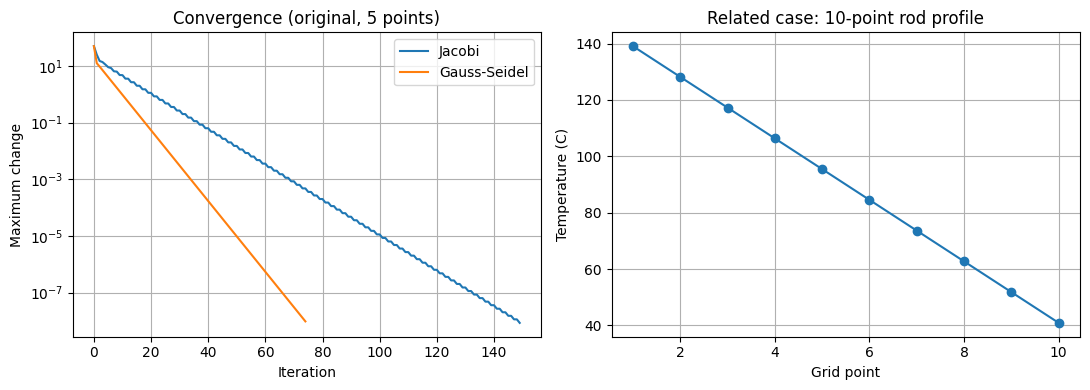

In [29]:
print("\n=== PART 3: Related case - metal rod, boundaries 150 C and 30 C, n points ===")
for n in (5, 10, 20, 40):
    An, bn = rod(n, 150., 30.)
    xj, ej = jacobi(An, bn, tol=1e-6, max_iter=20000)
    xg, eg = gauss_seidel(An, bn, tol=1e-6, max_iter=20000)
    print(f"n={n:3d}: Jacobi {len(ej):5d} iterations | Gauss-Seidel {len(eg):5d} iterations | max err GS {np.max(np.abs(xg-np.linalg.solve(An,bn))):.2e}")
An, bn = rod(10, 150., 30.)
xg, _ = gauss_seidel(An, bn, tol=1e-10, max_iter=20000)
print("10-point profile (GS):", np.round(xg, 3))
# note: right-hand side b holds boundary temperatures *as given* (b[0]=T_left, b[-1]=T_right) following the brief's model.

fig, ax = plt.subplots(1, 2, figsize=(11, 4))
ax[0].semilogy(err_j, label="Jacobi"); ax[0].semilogy(err_gs, label="Gauss-Seidel")
ax[0].set_xlabel("Iteration"); ax[0].set_ylabel("Maximum change"); ax[0].set_title("Convergence (original, 5 points)")
ax[0].legend(); ax[0].grid(True)
ax[1].plot(range(1, 11), xg, "o-"); ax[1].set_xlabel("Grid point"); ax[1].set_ylabel("Temperature (C)")
ax[1].set_title("Related case: 10-point rod profile"); ax[1].grid(True)
plt.tight_layout(); plt.show()

---
## Task 9 – Eigenvalues and Eigenvectors

Find the most influential nodes of a network from the dominant eigenvector; extended to PageRank.

In [30]:
import numpy as np

nodes = ["A", "B", "C", "D"]
def centrality(A):
    w, V = np.linalg.eig(A)
    i = np.argmax(np.real(w))
    lam = np.real(w[i]); v = np.real(V[:, i])
    c = np.abs(v) / np.abs(v).sum()
    return lam, v, c

**Part 1 – Original program** (from the brief, with extra checks).

In [31]:
print("=== PART 1: Original ===")
A = np.array([[0,1,1,0],[1,0,1,1],[1,1,0,1],[0,1,1,0]], dtype=float)
lam, v, c = centrality(A)
print("Dominant eigenvalue:", lam)
print("Eigenvector-based importance:")
for n_, s in zip(nodes, c):
    print(f"{n_}: {s:.4f}")
print("Verification error:", np.linalg.norm(A @ v - lam * v))
print("All eigenvalues:", np.round(np.sort(np.real(np.linalg.eigvals(A)))[::-1], 4))

=== PART 1: Original ===
Dominant eigenvalue: 2.5615528128088276
Eigenvector-based importance:
A: 0.2192
B: 0.2808
C: 0.2808
D: 0.2192
Verification error: 2.6921477609369894e-15
All eigenvalues: [ 2.5616 -0.     -1.     -1.5616]


**Part 2 – Changed input:** one or more parameters are changed to see how the result responds.

In [32]:
print("\n=== PART 2: Changed input - add link A-D ===")
A2 = A.copy(); A2[0, 3] = A2[3, 0] = 1
lam2, v2, c2 = centrality(A2)
print("Dominant eigenvalue:", round(lam2, 4), "(was", round(lam, 4), ")")
for n_, s in zip(nodes, c2):
    print(f"{n_}: {s:.4f}")


=== PART 2: Changed input - add link A-D ===
Dominant eigenvalue: 3.0 (was 2.5616 )
A: 0.2500
B: 0.2500
C: 0.2500
D: 0.2500


**Part 3 – Related real-world case:** the program adapted to a different problem.

In [33]:
print("\n=== PART 3: Related case - PageRank for 5 web pages (damping 0.85) ===")
pages = ["Home", "News", "Blog", "Shop", "About"]
# links[i, j] = 1 if page j links to page i
links = np.array([
    [0, 1, 1, 1, 1],
    [1, 0, 0, 0, 0],
    [1, 1, 0, 0, 0],
    [0, 0, 1, 0, 0],
    [0, 0, 0, 1, 0],
], dtype=float)
M = links / links.sum(axis=0)              # column-stochastic
d, n = 0.85, 5
G = d * M + (1 - d) / n * np.ones((n, n))  # Google matrix
r = np.ones(n) / n
for it in range(1, 200):
    r_new = G @ r
    if np.linalg.norm(r_new - r, 1) < 1e-12:
        break
    r = r_new
print(f"Power iteration converged in {it} steps")
w, V = np.linalg.eig(G)
ev = np.real(V[:, np.argmax(np.real(w))]); ev = ev / ev.sum()
for p, s, s2 in sorted(zip(pages, r, ev), key=lambda t: -t[1]):
    print(f"{p:6s} PageRank = {s:.4f} (eigenvector method {s2:.4f})")
print("Dominant eigenvalue of Google matrix:", round(np.max(np.real(w)), 6))


=== PART 3: Related case - PageRank for 5 web pages (damping 0.85) ===
Power iteration converged in 35 steps
Home   PageRank = 0.3456 (eigenvector method 0.3456)
Blog   PageRank = 0.2521 (eigenvector method 0.2521)
News   PageRank = 0.1769 (eigenvector method 0.1769)
Shop   PageRank = 0.1371 (eigenvector method 0.1371)
About  PageRank = 0.0883 (eigenvector method 0.0883)
Dominant eigenvalue of Google matrix: 1.0


---
## Task 10 – Root Finding: Bisection and Fixed-Point Methods

Find an equilibrium temperature (and break-even points) by bisection and fixed-point iteration.

In [34]:
import numpy as np
from scipy.optimize import root_scalar
import matplotlib.pyplot as plt

def bisect_manual(f, a, b, tol=1e-10):
    n = 0
    while (b - a) / 2 > tol:
        m = (a + b) / 2
        if f(a) * f(m) <= 0: b = m
        else: a = m
        n += 1
    return (a + b) / 2, n

def fixed_point(g, x0, tol=1e-10, max_iter=1000):
    x = x0; hist = [x]
    for _ in range(max_iter):
        xn = g(x); hist.append(xn)
        if abs(xn - x) < tol: break
        x = xn
    return hist

**Part 1 – Original program** (from the brief, with extra checks).

In [35]:
print("=== PART 1: Original ===")
def heat_balance(T): return T - 25 - 10*np.exp(-T/20)
solution = root_scalar(heat_balance, bracket=[20, 40], method="bisect", xtol=1e-10)
def g(T): return 25 + 10*np.exp(-T/20)
history = fixed_point(g, 30.0)
print(f"Bisection equilibrium temperature: {solution.root:.6f} C")
print(f"Fixed-point equilibrium temperature: {history[-1]:.6f} C")
print("Fixed-point iterations:", len(history) - 1)
r, n = bisect_manual(heat_balance, 20, 40)
print(f"Hand-written bisection: {r:.6f} C after {n} halvings (bracket width 20 -> {20/2**n:.2e})")
print("|g'(T*)| =", abs(-0.5*np.exp(-solution.root/20)), "< 1  -> fixed-point converges")

=== PART 1: Original ===
Bisection equilibrium temperature: 27.525211 C
Fixed-point equilibrium temperature: 27.525211 C
Fixed-point iterations: 13
Hand-written bisection: 27.525211 C after 37 halvings (bracket width 20 -> 1.46e-10)
|g'(T*)| = 0.12626054096485964 < 1  -> fixed-point converges


**Part 2 – Changed input:** one or more parameters are changed to see how the result responds.

In [36]:
print("\n=== PART 2: Changed input - ambient 25 -> 35 C and heat-source 10 -> 40 ===")
def hb2(T, amb=35, src=40): return T - amb - src*np.exp(-T/20)
s2 = root_scalar(hb2, bracket=[20, 80], method="bisect", xtol=1e-10)
h2 = fixed_point(lambda T: 35 + 40*np.exp(-T/20), 30.0)
print(f"New equilibrium (bisection): {s2.root:.6f} C | fixed-point: {h2[-1]:.6f} C | iterations {len(h2)-1}")
print("|g'| at root =", round(abs(-2*np.exp(-s2.root/20)), 4))
_, n_tight = bisect_manual(heat_balance, 20, 40, 1e-4)
_, n_loose = bisect_manual(heat_balance, 20, 40, 1e-12)
print(f"Halvings for tol 1e-4: {n_tight} | tol 1e-12: {n_loose}")


=== PART 2: Changed input - ambient 25 -> 35 C and heat-source 10 -> 40 ===
New equilibrium (bisection): 40.325912 C | fixed-point: 40.325912 C | iterations 21
|g'| at root = 0.2663
Halvings for tol 1e-4: 17 | tol 1e-12: 44


**Part 3 – Related real-world case:** the program adapted to a different problem.


=== PART 3: Related case - break-even points of profit(q) = 300*sqrt(q) - 4000 - 5q ===
Lower break-even: 400.0000 units | Upper break-even: 1600.0000 units
Profit at 400: 0.0000 | at 1600: 0.0000 | at 1000 (between): 486.83
Maximum profit at q=900: 500.00


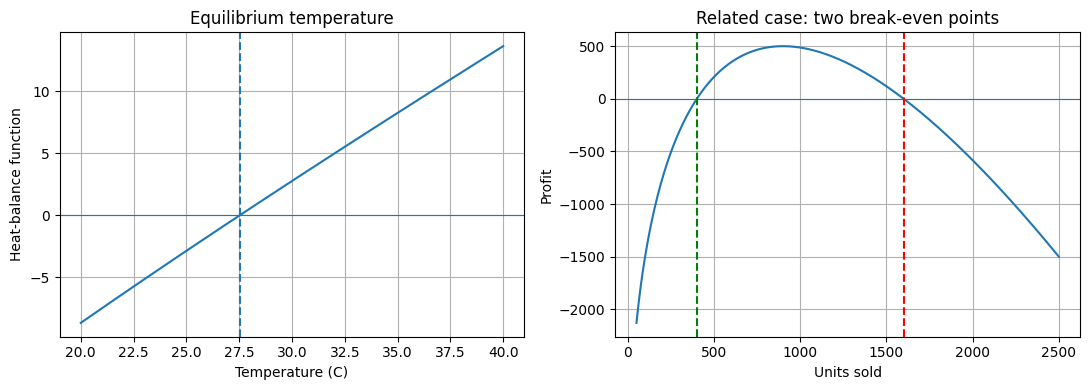

In [37]:
print("\n=== PART 3: Related case - break-even points of profit(q) = 300*sqrt(q) - 4000 - 5q ===")
def profit(q): return 300*np.sqrt(q) - 4000 - 5*q
lo = root_scalar(profit, bracket=[100, 1000], method="bisect", xtol=1e-9)
hi = root_scalar(profit, bracket=[1000, 2500], method="bisect", xtol=1e-9)
print(f"Lower break-even: {lo.root:.4f} units | Upper break-even: {hi.root:.4f} units")
print(f"Profit at 400: {profit(400):.4f} | at 1600: {profit(1600):.4f} | at 1000 (between): {profit(1000):.2f}")
q_best = 900  # maximiser: d/dq = 150/sqrt(q) - 5 = 0
print(f"Maximum profit at q={q_best}: {profit(q_best):.2f}")

temps = np.linspace(20, 40, 300)
fig, ax = plt.subplots(1, 2, figsize=(11, 4))
ax[0].plot(temps, heat_balance(temps)); ax[0].axhline(0, lw=0.8); ax[0].axvline(solution.root, ls="--")
ax[0].set_xlabel("Temperature (C)"); ax[0].set_ylabel("Heat-balance function"); ax[0].set_title("Equilibrium temperature"); ax[0].grid(True)
q = np.linspace(50, 2500, 400)
ax[1].plot(q, profit(q)); ax[1].axhline(0, lw=0.8)
ax[1].axvline(lo.root, ls="--", c="g"); ax[1].axvline(hi.root, ls="--", c="r")
ax[1].set_xlabel("Units sold"); ax[1].set_ylabel("Profit"); ax[1].set_title("Related case: two break-even points"); ax[1].grid(True)
plt.tight_layout(); plt.show()

---
## Task 11 – Root Finding: Newton-Raphson and Secant Methods

Compute an internal rate of return (and a loan rate) where NPV equals zero.

In [38]:
import numpy as np
from scipy.optimize import root_scalar

def make_npv(cash_flows):
    def npv(rate): return sum(cf / (1 + rate)**t for t, cf in enumerate(cash_flows))
    def d_npv(rate): return sum(-t * cf / (1 + rate)**(t + 1) for t, cf in enumerate(cash_flows) if t > 0)
    return npv, d_npv

def newton_manual(f, df, x0, tol=1e-12, max_iter=50):
    x = x0; hist = [x]
    for _ in range(max_iter):
        xn = x - f(x)/df(x); hist.append(xn)
        if abs(xn - x) < tol: break
        x = xn
    return hist

**Part 1 – Original program** (from the brief, with extra checks).

In [39]:
print("=== PART 1: Original ===")
cash_flows = [-10000, 3000, 3500, 4000, 2500]
npv, d_npv = make_npv(cash_flows)
newton = root_scalar(npv, fprime=d_npv, x0=0.10, method="newton", xtol=1e-12)
secant = root_scalar(npv, x0=0.05, x1=0.20, method="secant", xtol=1e-12)
print(f"IRR using Newton-Raphson: {newton.root:.6%}")
print(f"IRR using Secant method: {secant.root:.6%}")
print(f"NPV at Newton solution: {npv(newton.root):.6f}")
print("Newton iterations (scipy):", newton.iterations, "| Secant iterations:", secant.iterations)
h = newton_manual(npv, d_npv, 0.10)
print("Manual Newton iterates:", [f"{v:.8f}" for v in h])
print("Textbook check, f(x)=x^2-2 from x0=1.5:", [round(v, 6) for v in newton_manual(lambda x: x*x-2, lambda x: 2*x, 1.5)])

=== PART 1: Original ===
IRR using Newton-Raphson: 11.542461%
IRR using Secant method: 11.542461%
NPV at Newton solution: 0.000000
Newton iterations (scipy): 4 | Secant iterations: 7
Manual Newton iterates: ['0.10000000', '0.11502117', '0.11542433', '0.11542461', '0.11542461']
Textbook check, f(x)=x^2-2 from x0=1.5: [1.5, 1.416667, 1.414216, 1.414214, 1.414214, 1.414214]


**Part 2 – Changed input:** one or more parameters are changed to see how the result responds.

In [40]:
print("\n=== PART 2: Changed input - larger final cash flow and different start ===")
cf2 = [-10000, 3000, 3500, 4000, 5500]
npv2, d2 = make_npv(cf2)
n2 = root_scalar(npv2, fprime=d2, x0=0.10, method="newton", xtol=1e-12)
print(f"IRR with final inflow 5500: {n2.root:.4%} (was {newton.root:.4%})")
import warnings
warnings.filterwarnings("ignore")
for x0 in (0.10, 0.50, 2.0):
    r = root_scalar(npv, fprime=d_npv, x0=x0, method="newton", xtol=1e-12)
    ok = abs(npv(r.root)) < 1e-6 and r.root > -1
    if ok:
        print(f"Start x0={x0}: root {r.root:.6%} in {r.iterations} iterations")
    else:
        print(f"Start x0={x0}: Newton DIVERGED (|NPV| at 'root' is not ~0) - a poor start can fail")


=== PART 2: Changed input - larger final cash flow and different start ===
IRR with final inflow 5500: 19.5116% (was 11.5425%)
Start x0=0.1: root 11.542461% in 4 iterations
Start x0=0.5: root 11.542461% in 8 iterations
Start x0=2.0: Newton DIVERGED (|NPV| at 'root' is not ~0) - a poor start can fail


**Part 3 – Related real-world case:** the program adapted to a different problem.

In [41]:
print("\n=== PART 3: Related case - loan APR from payment ===")
# Loan of 12,000 repaid with 36 monthly payments of 380. Find monthly rate r.
P, pay, n = 12000.0, 380.0, 36
def f(r): return P - pay * (1 - (1 + r)**(-n)) / r
def df(r):
    return -pay * (n*(1+r)**(-n-1)/r - (1 - (1+r)**(-n))/r**2)
nw = root_scalar(f, fprime=df, x0=0.02, method="newton", xtol=1e-14)
sc = root_scalar(f, x0=0.005, x1=0.03, method="secant", xtol=1e-14)
print(f"Monthly rate (Newton): {nw.root:.6%} in {nw.iterations} iterations")
print(f"Monthly rate (Secant): {sc.root:.6%} in {sc.iterations} iterations")
print(f"Nominal APR = 12 x monthly = {12*nw.root:.4%}")
print(f"Effective annual rate = {(1+nw.root)**12-1:.4%}")
print(f"Total repaid {pay*n:.0f} -> interest cost {pay*n-P:.0f}")
print(f"Check payment at root: {P*nw.root/(1-(1+nw.root)**-n):.6f}")


=== PART 3: Related case - loan APR from payment ===
Monthly rate (Newton): 0.726144% in 6 iterations
Monthly rate (Secant): 0.726144% in 7 iterations
Nominal APR = 12 x monthly = 8.7137%
Effective annual rate = 9.0703%
Total repaid 13680 -> interest cost 1680
Check payment at root: 380.000000


---
## Task 12 – Polynomial and Nonlinear Equation Solving

Find intersections of a circle and a parabola by solving two nonlinear equations.

In [42]:
import numpy as np
from scipy.optimize import root
import matplotlib.pyplot as plt

In [43]:
print("=== PART 0: Polynomial x^2 - 5x + 6 = 0 ===")
print("np.roots:", np.roots([1, -5, 6]))

def make_eq(r2):
    def equations(z):
        x, y = z
        return [x**2 + y**2 - r2, y - (x**2 - 1)]
    return equations

=== PART 0: Polynomial x^2 - 5x + 6 = 0 ===
np.roots: [3. 2.]


**Part 1 – Original program** (from the brief, with extra checks).

In [44]:
print("\n=== PART 1: Original - circle r=2 and parabola y=x^2-1 ===")
equations = make_eq(4)
for guess in ([1.0, 1.0], [-1.0, 1.0]):
    sol = root(equations, guess)
    print("Initial guess:", guess); print("Intersection:", sol.x)
    print("Residuals:", [float(f"{r:.2e}") for r in equations(sol.x)]); print("Converged:", sol.success); print()
sol = root(equations, [1.0, -2.0])
print("Guess [1,-2] (lower region; no real intersection exists there):", np.round(sol.x, 4), "| residuals", np.round(equations(sol.x), 6), "| success:", sol.success)
print("Exact check: y = (-1+sqrt(13))/2 =", (-1 + np.sqrt(13))/2, "; x = +/-", np.sqrt((-1 + np.sqrt(13))/2 + 1))


=== PART 1: Original - circle r=2 and parabola y=x^2-1 ===
Initial guess: [1.0, 1.0]
Intersection: [1.51748991 1.30277564]
Residuals: [-2.48e-13, -2.42e-13]
Converged: True

Initial guess: [-1.0, 1.0]
Intersection: [-1.51748991  1.30277564]
Residuals: [-2.48e-13, -2.42e-13]
Converged: True

Guess [1,-2] (lower region; no real intersection exists there): [-3.0000e-04 -1.9384e+00] | residuals [-0.242706 -0.938374] | success: False
Exact check: y = (-1+sqrt(13))/2 = 1.3027756377319946 ; x = +/- 1.5174899135519797


**Part 2 – Changed input:** one or more parameters are changed to see how the result responds.

In [45]:
print("\n=== PART 2: Changed input - circle radius 2 -> 1 (r^2 = 1), then 3 ===")
for r2 in (1, 9):
    eq = make_eq(r2)
    found = set()
    for g in ([1, 1], [-1, 1], [1, -2], [-1, -2], [0.5, 0], [2, 3]):
        s = root(eq, g)
        if s.success and np.linalg.norm(eq(s.x)) < 1e-9:
            found.add(tuple(float(v) for v in np.round(s.x, 5)))
    print(f"r^2 = {r2}: intersections found -> {sorted(found)}")


=== PART 2: Changed input - circle radius 2 -> 1 (r^2 = 1), then 3 ===
r^2 = 1: intersections found -> [(-1.0, 0.0), (0.0, -1.0), (1.0, 0.0)]
r^2 = 9: intersections found -> [(-1.83638, 2.37228), (1.83638, 2.37228)]


**Part 3 – Related real-world case:** the program adapted to a different problem.


=== PART 3: Related case - 2-beacon position fix (trilateration) ===
Guess [2.0, 3.0] -> [3. 4.] | residuals [-0. -0.]
Guess [2.0, -3.0] -> [ 3. -4.] | residuals [-0. -0.]
Ambiguity: two beacons give TWO candidate positions; a third beacon is needed.
Third beacon at (3,8), dist 4 -> least-squares fix: [3. 4.] cost 0.0
From the upper guess: [3. 4.] cost 6.31e-30


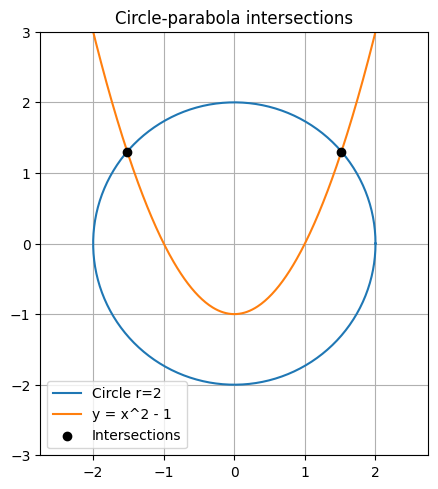

In [46]:
print("\n=== PART 3: Related case - 2-beacon position fix (trilateration) ===")
# Beacon 1 at (0,0), distance 5; beacon 2 at (6,0), distance 5.
def beacons(z):
    x, y = z
    return [x**2 + y**2 - 5.0**2, (x - 6.0)**2 + y**2 - 5.0**2]
for guess in ([2.0, 3.0], [2.0, -3.0]):
    s = root(beacons, guess)
    print("Guess", guess, "->", np.round(s.x, 6), "| residuals", np.round(beacons(s.x), 10))
print("Ambiguity: two beacons give TWO candidate positions; a third beacon is needed.")
def beacons3(z):
    x, y = z
    return [x**2 + y**2 - 25.0, (x - 6.0)**2 + y**2 - 25.0, (x - 3.0)**2 + (y - 8.0)**2 - 16.0]
from scipy.optimize import least_squares
ls = least_squares(beacons3, [2.0, -3.0])
print("Third beacon at (3,8), dist 4 -> least-squares fix:", np.round(ls.x, 4), "cost", round(ls.cost, 6))
ls2 = least_squares(beacons3, [2.0, 3.0])
print("From the upper guess:", np.round(ls2.x, 4), "cost", f"{ls2.cost:.2e}")

t = np.linspace(0, 2*np.pi, 400); xs = np.linspace(-2.5, 2.5, 400)
plt.figure(figsize=(5.5, 5.5))
plt.plot(2*np.cos(t), 2*np.sin(t), label="Circle r=2"); plt.plot(xs, xs**2 - 1, label="y = x^2 - 1")
pts = []
for g in ([1.0, 1.0], [-1.0, 1.0]): pts.append(root(equations, g).x)
pts = np.array(pts); plt.scatter(pts[:, 0], pts[:, 1], c="k", zorder=5, label="Intersections")
plt.ylim(-3, 3); plt.gca().set_aspect("equal"); plt.grid(True); plt.legend()
plt.title("Circle-parabola intersections"); plt.show()

---
## Task 13 – Interpolation

Estimate temperatures between hourly readings with linear and cubic-spline interpolation.

In [47]:
import numpy as np
from scipy.interpolate import interp1d, CubicSpline
import matplotlib.pyplot as plt

**Part 1 – Original program** (from the brief, with extra checks).

In [48]:
print("=== PART 1: Original ===")
hours = np.array([8, 9, 10, 11, 12, 13, 14], dtype=float)
temperature = np.array([18.0, 20.0, 22.5, 24.0, 25.0, 25.5, 25.0])
linear = interp1d(hours, temperature, kind="linear"); cubic = CubicSpline(hours, temperature)
ten_minute_times = np.arange(8, 14 + 1/6, 1/6)
linear_estimates, cubic_estimates = linear(ten_minute_times), cubic(ten_minute_times)
print(f"Linear estimate at 10:30: {float(linear(10.5)):.2f} C")
print(f"Cubic estimate at 10:30: {float(cubic(10.5)):.2f} C")
print("Number of 10-minute estimates:", len(ten_minute_times))
print(f"Worked example check: 20C at 10:00, 24C at 12:00 -> {float(interp1d([10,12],[20,24])(11)):.1f} C at 11:00")

=== PART 1: Original ===
Linear estimate at 10:30: 23.25 C
Cubic estimate at 10:30: 23.36 C
Number of 10-minute estimates: 37
Worked example check: 20C at 10:00, 24C at 12:00 -> 22.0 C at 11:00


**Part 2 – Changed input:** one or more parameters are changed to see how the result responds.

In [49]:
print("\n=== PART 2: Changed input - quadratic interp, then change the 10:00 reading 22.5 -> 26.5 ===")
quad = interp1d(hours, temperature, kind="quadratic")
print(f"Quadratic at 10:30: {float(quad(10.5)):.3f} C")
t2 = temperature.copy(); t2[2] = 26.5
print(f"Linear at 10:30 with new reading: {float(interp1d(hours, t2)(10.5)):.3f} C | cubic: {float(CubicSpline(hours, t2)(10.5)):.3f} C")
print("Cubic spline overshoot with bad reading, max between 9 and 11:", round(float(CubicSpline(hours, t2)(np.linspace(9, 11, 200)).max()), 3))
try:
    linear(15.0)
except ValueError as e:
    print("Extrapolation at 15:00 raises ValueError ->", str(e)[:60])


=== PART 2: Changed input - quadratic interp, then change the 10:00 reading 22.5 -> 26.5 ===
Quadratic at 10:30: 23.360 C
Linear at 10:30 with new reading: 25.250 C | cubic: 25.680 C
Cubic spline overshoot with bad reading, max between 9 and 11: 26.57
Extrapolation at 15:00 raises ValueError -> A value (15.0) in x_new is above the interpolation range's m


**Part 3 – Related real-world case:** the program adapted to a different problem.


=== PART 3: Related case - PM2.5 sensor with missing readings, scored against truth ===
Missing hours: [ 5.  6.  7. 14. 15.]
True   : [48.66 47.   48.66 17.   15.2 ]
Linear : [52.32 52.32 52.32 22.   19.84] | RMSE 4.509
Cubic  : [50.16 49.43 50.16 17.75 15.91] | RMSE 1.513


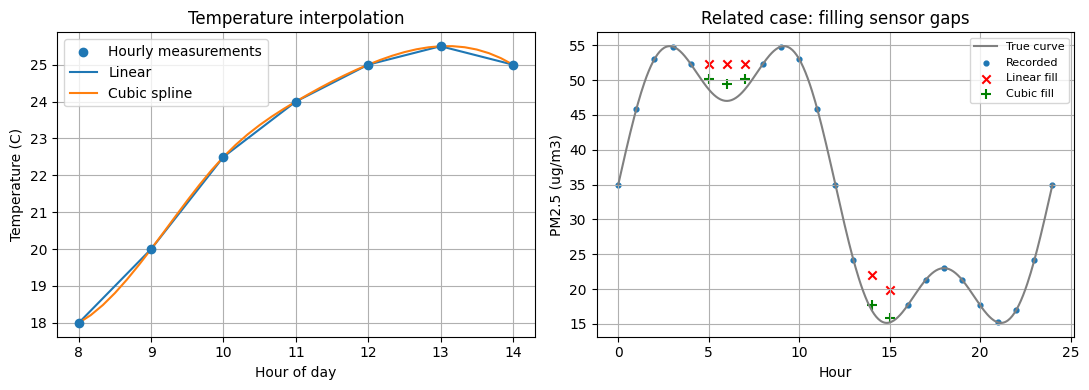

In [50]:
print("\n=== PART 3: Related case - PM2.5 sensor with missing readings, scored against truth ===")
t_full = np.arange(0, 25, 1.0)
true_pm = 35 + 20*np.sin(2*np.pi*t_full/24) + 8*np.sin(2*np.pi*t_full/8)
missing = np.array([5, 6, 7, 14, 15])
keep = np.setdiff1d(np.arange(len(t_full)), missing)
lin = interp1d(t_full[keep], true_pm[keep])(t_full[missing])
cub = CubicSpline(t_full[keep], true_pm[keep])(t_full[missing])
print("Missing hours:", t_full[missing])
print("True   :", np.round(true_pm[missing], 2))
print("Linear :", np.round(lin, 2), "| RMSE", round(float(np.sqrt(np.mean((lin - true_pm[missing])**2))), 3))
print("Cubic  :", np.round(cub, 2), "| RMSE", round(float(np.sqrt(np.mean((cub - true_pm[missing])**2))), 3))

fig, ax = plt.subplots(1, 2, figsize=(11, 4))
ax[0].scatter(hours, temperature, label="Hourly measurements", zorder=5)
ax[0].plot(ten_minute_times, linear_estimates, label="Linear"); ax[0].plot(ten_minute_times, cubic_estimates, label="Cubic spline")
ax[0].set_xlabel("Hour of day"); ax[0].set_ylabel("Temperature (C)"); ax[0].set_title("Temperature interpolation"); ax[0].legend(); ax[0].grid(True)
tt = np.linspace(0, 24, 400)
ax[1].plot(tt, 35 + 20*np.sin(2*np.pi*tt/24) + 8*np.sin(2*np.pi*tt/8), c="grey", label="True curve")
ax[1].scatter(t_full[keep], true_pm[keep], s=12, label="Recorded"); ax[1].scatter(t_full[missing], lin, marker="x", c="r", label="Linear fill")
ax[1].scatter(t_full[missing], cub, marker="+", c="g", s=60, label="Cubic fill")
ax[1].set_xlabel("Hour"); ax[1].set_ylabel("PM2.5 (ug/m3)"); ax[1].set_title("Related case: filling sensor gaps"); ax[1].legend(fontsize=8); ax[1].grid(True)
plt.tight_layout(); plt.show()

---
## Task 14 – Curve Fitting and Approximation

Fit a curve to server response-time data by least squares and check the residuals.

In [51]:
import numpy as np
from scipy.optimize import curve_fit
import matplotlib.pyplot as plt

users = np.array([50, 100, 150, 200, 250, 300, 350], dtype=float)
response_ms = np.array([82, 95, 115, 145, 185, 238, 305], dtype=float)
def model(x, a, b, c): return a*x**2 + b*x + c
rmse = lambda y, p: float(np.sqrt(np.mean((y - p)**2)))

**Part 1 – Original program** (from the brief, with extra checks).

In [52]:
print("=== PART 1: Original - quadratic ===")
parameters, covariance = curve_fit(model, users, response_ms)
a, b, c = parameters
predicted = model(users, a, b, c)
print(f"Fitted model: y = {a:.6f}x^2 + {b:.4f}x + {c:.2f}")
print(f"RMSE: {rmse(response_ms, predicted):.2f} ms")
print(f"Predicted response at 400 users: {model(400, a, b, c):.2f} ms")
print("Residuals:", np.round(response_ms - predicted, 2))
print("Parameter standard errors:", np.round(np.sqrt(np.diag(covariance)), 6))

=== PART 1: Original - quadratic ===
Fitted model: y = 0.002167x^2 + -0.1345x + 85.00
RMSE: 1.55 ms
Predicted response at 400 users: 377.86 ms
Residuals: [-1.69  1.79  1.43  0.24 -1.79 -1.64  1.67]
Parameter standard errors: [8.900000e-05 3.661600e-02 3.194649e+00]


**Part 2 – Changed input:** one or more parameters are changed to see how the result responds.

In [53]:
print("\n=== PART 2: Changed model - straight line and exponential ===")
lin = np.polyfit(users, response_ms, 1)
print(f"Linear: y = {lin[0]:.4f}x + {lin[1]:.2f} | RMSE {rmse(response_ms, np.polyval(lin, users)):.2f} | at 400: {np.polyval(lin, 400):.1f} ms")
def expo(x, a, b, c): return a*np.exp(b*x) + c
pe, _ = curve_fit(expo, users, response_ms, p0=[10, 0.01, 70], maxfev=20000)
print(f"Exponential: y = {pe[0]:.3f}*exp({pe[1]:.5f}x) + {pe[2]:.2f} | RMSE {rmse(response_ms, expo(users, *pe)):.2f} | at 400: {expo(400, *pe):.1f} ms")
print("Order-3 polynomial RMSE:", round(rmse(response_ms, np.polyval(np.polyfit(users, response_ms, 3), users)), 3), "(overfits 7 points with 4 parameters)")


=== PART 2: Changed model - straight line and exponential ===
Linear: y = 0.7321x + 20.00 | RMSE 18.83 | at 400: 312.9 ms
Exponential: y = 33.654*exp(0.00596x) + 34.72 | RMSE 1.43 | at 400: 400.4 ms
Order-3 polynomial RMSE: 0.143 (overfits 7 points with 4 parameters)


**Part 3 – Related real-world case:** the program adapted to a different problem.


=== PART 3: Related case - logistic growth of app users (synthetic noisy data) ===
True   K=5000, r=0.45, t0=9
Fitted K=4971.2, r=0.464, t0=8.97 | RMSE 107.2 users
Std errors: [5.8019e+01 2.0000e-02 1.1200e-01]
Predicted users in week 25: 4968 | carrying capacity K ~ 4971
R^2 = 0.9969
Fit using only weeks 0-8: K=6111 (true 5000) -> extrapolation is unreliable


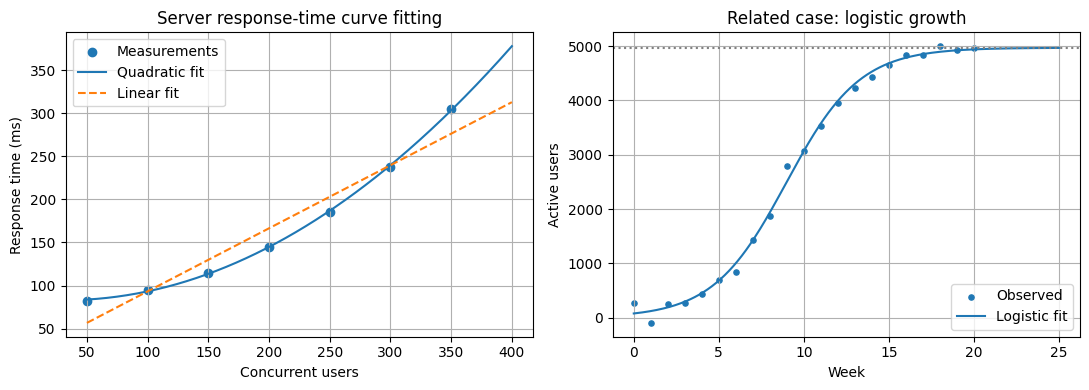

In [54]:
print("\n=== PART 3: Related case - logistic growth of app users (synthetic noisy data) ===")
rng = np.random.default_rng(3)
weeks = np.arange(0, 21, dtype=float)
def logistic(t, K, r, t0): return K / (1 + np.exp(-r*(t - t0)))
true = (5000, 0.45, 9)
obs = logistic(weeks, *true) + rng.normal(0, 90, weeks.size)
p, cov = curve_fit(logistic, weeks, obs, p0=[4000, 0.3, 8])
print(f"True   K={true[0]}, r={true[1]}, t0={true[2]}")
print(f"Fitted K={p[0]:.1f}, r={p[1]:.3f}, t0={p[2]:.2f} | RMSE {rmse(obs, logistic(weeks, *p)):.1f} users")
print("Std errors:", np.round(np.sqrt(np.diag(cov)), 3))
print(f"Predicted users in week 25: {logistic(25, *p):.0f} | carrying capacity K ~ {p[0]:.0f}")
ss_res = np.sum((obs - logistic(weeks, *p))**2); ss_tot = np.sum((obs - obs.mean())**2)
print(f"R^2 = {1 - ss_res/ss_tot:.4f}")
# fitting only early weeks: how well is K recovered?
early = weeks <= 8
pe2, _ = curve_fit(logistic, weeks[early], obs[early], p0=[4000, 0.3, 8], maxfev=20000)
print(f"Fit using only weeks 0-8: K={pe2[0]:.0f} (true 5000) -> extrapolation is unreliable")

x_plot = np.linspace(users.min(), 400, 300)
fig, ax = plt.subplots(1, 2, figsize=(11, 4))
ax[0].scatter(users, response_ms, label="Measurements"); ax[0].plot(x_plot, model(x_plot, a, b, c), label="Quadratic fit")
ax[0].plot(x_plot, np.polyval(lin, x_plot), "--", label="Linear fit")
ax[0].set_xlabel("Concurrent users"); ax[0].set_ylabel("Response time (ms)"); ax[0].set_title("Server response-time curve fitting"); ax[0].legend(); ax[0].grid(True)
w = np.linspace(0, 25, 300)
ax[1].scatter(weeks, obs, s=14, label="Observed"); ax[1].plot(w, logistic(w, *p), label="Logistic fit")
ax[1].axhline(p[0], ls=":", c="grey"); ax[1].set_xlabel("Week"); ax[1].set_ylabel("Active users"); ax[1].set_title("Related case: logistic growth"); ax[1].legend(); ax[1].grid(True)
plt.tight_layout(); plt.show()

---
## Task 15 – Numerical Differentiation

Estimate speed from GPS positions using forward, central and backward differences.

In [55]:
import numpy as np
import matplotlib.pyplot as plt

def estimate_speed(time, position):
    speed = np.zeros_like(position)
    speed[0] = (position[1] - position[0]) / (time[1] - time[0])
    for i in range(1, len(time) - 1):
        speed[i] = (position[i + 1] - position[i - 1]) / (time[i + 1] - time[i - 1])
    speed[-1] = (position[-1] - position[-2]) / (time[-1] - time[-2])
    return speed

**Part 1 – Original program** (from the brief, with extra checks).

In [56]:
print("=== PART 1: Original - GPS speed ===")
time = np.array([0, 1, 2, 3, 4, 5, 6], dtype=float)
position = np.array([0.0, 4.8, 10.2, 16.1, 22.7, 30.0, 38.0])
speed = estimate_speed(time, position)
for t, x, v in zip(time, position, speed):
    print(f"t={t:.0f}s, position={x:.1f}m, estimated speed={v:.2f}m/s")
print("np.gradient check:", np.round(np.gradient(position, time), 2))
print("Worked example: (112-100)/2 =", (112-100)/2, "m/s")

=== PART 1: Original - GPS speed ===
t=0s, position=0.0m, estimated speed=4.80m/s
t=1s, position=4.8m, estimated speed=5.10m/s
t=2s, position=10.2m, estimated speed=5.65m/s
t=3s, position=16.1m, estimated speed=6.25m/s
t=4s, position=22.7m, estimated speed=6.95m/s
t=5s, position=30.0m, estimated speed=7.65m/s
t=6s, position=38.0m, estimated speed=8.00m/s
np.gradient check: [4.8  5.1  5.65 6.25 6.95 7.65 8.  ]
Worked example: (112-100)/2 = 6.0 m/s


**Part 2 – Changed input:** one or more parameters are changed to see how the result responds.

In [57]:
print("\n=== PART 2: Changed input - step size h for f(x)=sin(x) at x=1 (exact cos(1)) ===")
exact = np.cos(1.0)
print(f"{'h':>8} {'forward err':>14} {'central err':>14}")
for h in (1.0, 0.1, 0.01, 0.001, 1e-6, 1e-10, 1e-14):
    fwd = (np.sin(1 + h) - np.sin(1)) / h
    cen = (np.sin(1 + h) - np.sin(1 - h)) / (2*h)
    print(f"{h:8.0e} {abs(fwd-exact):14.3e} {abs(cen-exact):14.3e}")
print("Changing GPS sample 4s position 22.7 -> 24.7 (a GPS glitch):")
pos2 = position.copy(); pos2[4] = 24.7
print("  speeds:", np.round(estimate_speed(time, pos2), 2))


=== PART 2: Changed input - step size h for f(x)=sin(x) at x=1 (exact cos(1)) ===
       h    forward err    central err
   1e+00      4.725e-01      8.565e-02
   1e-01      4.294e-02      9.001e-04
   1e-02      4.216e-03      9.005e-06
   1e-03      4.208e-04      9.005e-08
   1e-06      4.207e-07      2.772e-11
   1e-10      5.848e-08      5.848e-08
   1e-14      3.707e-03      3.707e-03
Changing GPS sample 4s position 22.7 -> 24.7 (a GPS glitch):
  speeds: [4.8  5.1  5.65 7.25 6.95 6.65 8.  ]


**Part 3 – Related real-world case:** the program adapted to a different problem.


=== PART 3: Related case - train acceleration from velocity data ===
t= 0s v=  0.0 m/s a= 1.90 m/s^2
t= 1s v=  1.9 m/s a= 1.90 m/s^2
t= 2s v=  3.8 m/s a= 1.75 m/s^2
t= 3s v=  5.4 m/s a= 1.55 m/s^2
t= 4s v=  6.9 m/s a= 1.35 m/s^2
t= 5s v=  8.1 m/s a= 1.05 m/s^2
t= 6s v=  9.0 m/s a= 0.75 m/s^2
t= 7s v=  9.6 m/s a= 0.50 m/s^2
t= 8s v= 10.0 m/s a= 0.30 m/s^2
t= 9s v= 10.2 m/s a= 0.15 m/s^2
t=10s v= 10.3 m/s a= 0.10 m/s^2
Peak acceleration: 1.90 m/s^2 at t=0 s
Second-order edges (edge_order=2) at t=0: 1.900 vs first-order 1.900


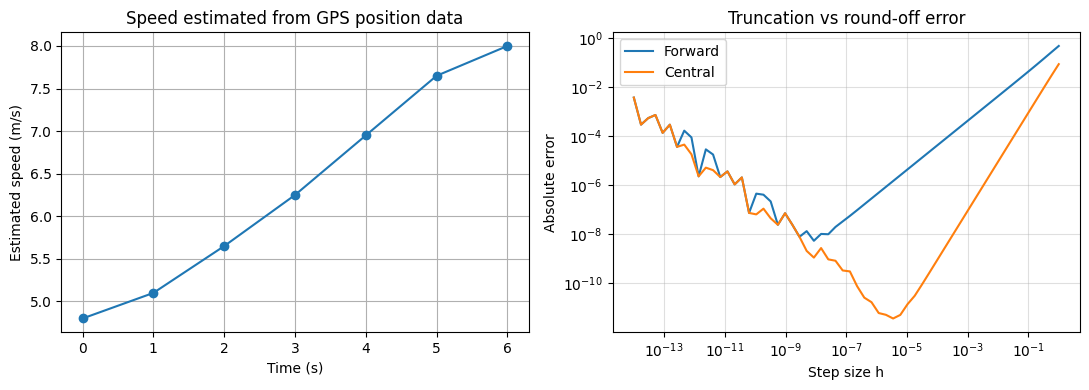

In [58]:
print("\n=== PART 3: Related case - train acceleration from velocity data ===")
tt = np.arange(0, 11, 1.0)
vel = np.array([0.0, 1.9, 3.8, 5.4, 6.9, 8.1, 9.0, 9.6, 10.0, 10.2, 10.3])  # m/s
acc = np.gradient(vel, tt)
for t_, v_, a_ in zip(tt, vel, acc):
    print(f"t={t_:2.0f}s v={v_:5.1f} m/s a={a_:5.2f} m/s^2")
print(f"Peak acceleration: {acc.max():.2f} m/s^2 at t={tt[acc.argmax()]:.0f} s")
print(f"Second-order edges (edge_order=2) at t=0: {np.gradient(vel, tt, edge_order=2)[0]:.3f} vs first-order {acc[0]:.3f}")

fig, ax = plt.subplots(1, 2, figsize=(11, 4))
ax[0].plot(time, speed, "o-"); ax[0].set_xlabel("Time (s)"); ax[0].set_ylabel("Estimated speed (m/s)"); ax[0].set_title("Speed estimated from GPS position data"); ax[0].grid(True)
hs = np.logspace(-14, 0, 60)
ax[1].loglog(hs, np.abs((np.sin(1+hs)-np.sin(1))/hs - exact), label="Forward"); ax[1].loglog(hs, np.abs((np.sin(1+hs)-np.sin(1-hs))/(2*hs) - exact), label="Central")
ax[1].set_xlabel("Step size h"); ax[1].set_ylabel("Absolute error"); ax[1].set_title("Truncation vs round-off error"); ax[1].legend(); ax[1].grid(True, which="both", alpha=0.4)
plt.tight_layout(); plt.show()

---
## Task 16 – Numerical Integration

Estimate total energy from smart-meter power readings with the trapezoidal and Simpson rules.

In [59]:
import numpy as np
from scipy.integrate import simpson, quad
import matplotlib.pyplot as plt

**Part 1 – Original program** (from the brief, with extra checks).

In [60]:
print("=== PART 1: Original - smart meter ===")
time_hours = np.array([0, 2, 4, 6, 8, 10, 12], dtype=float)
power_kw = np.array([0.8, 1.0, 1.4, 1.8, 1.6, 1.2, 0.9])
energy_trapezoid = np.trapezoid(power_kw, time_hours)
energy_simpson = simpson(power_kw, x=time_hours)
print(f"Energy using trapezoidal rule: {energy_trapezoid:.3f} kWh")
print(f"Energy using Simpson's rule: {energy_simpson:.3f} kWh")
print(f"Difference between estimates: {abs(energy_simpson-energy_trapezoid):.3f} kWh")
print("Constant 2 kW for 3 h:", np.trapezoid([2, 2], [0, 3]), "kWh")

=== PART 1: Original - smart meter ===
Energy using trapezoidal rule: 15.700 kWh
Energy using Simpson's rule: 15.800 kWh
Difference between estimates: 0.100 kWh
Constant 2 kW for 3 h: 6.0 kWh


**Part 2 – Changed input:** one or more parameters are changed to see how the result responds.

In [61]:
print("\n=== PART 2: Changed input - readings every 4 h (sub-sample) and a spike at 6 h (1.8 -> 3.0) ===")
t4, p4 = time_hours[::2], power_kw[::2]
print(f"Every 4 h: trapezoid {np.trapezoid(p4, t4):.3f} | Simpson {simpson(p4, x=t4):.3f} kWh")
p_spike = power_kw.copy(); p_spike[3] = 3.0
print(f"Spike at 6 h: trapezoid {np.trapezoid(p_spike, time_hours):.3f} | Simpson {simpson(p_spike, x=time_hours):.3f} kWh")


=== PART 2: Changed input - readings every 4 h (sub-sample) and a spike at 6 h (1.8 -> 3.0) ===
Every 4 h: trapezoid 15.400 | Simpson 15.967 kWh
Spike at 6 h: trapezoid 18.100 | Simpson 19.000 kWh


**Part 3 – Related real-world case:** the program adapted to a different problem.


=== PART 3: Related case - water flow Q(t) = 5 + 3 sin(pi t / 6) L/s, t in [0,12] h -> exact volume known ===
Exact volume = 216,000 L | quad: 216,000 L (error est 6.7e-13)
Exact volume over the first 4 h = 102,939.7 L
(Over the full 12 h the sine term is a whole period, so even the trapezoid rule is exact - see note in docs.)
n=  3 points on [0,4]: trapezoid err   2880.498 L | Simpson err 237.193599 L
n=  5 points on [0,4]: trapezoid err    710.109 L | Simpson err  13.353424 L
n=  9 points on [0,4]: trapezoid err    176.917 L | Simpson err   0.814091 L
n= 25 points on [0,4]: trapezoid err     19.637 L | Simpson err   0.009978 L
n=101 points on [0,4]: trapezoid err      1.131 L | Simpson err   0.000033 L


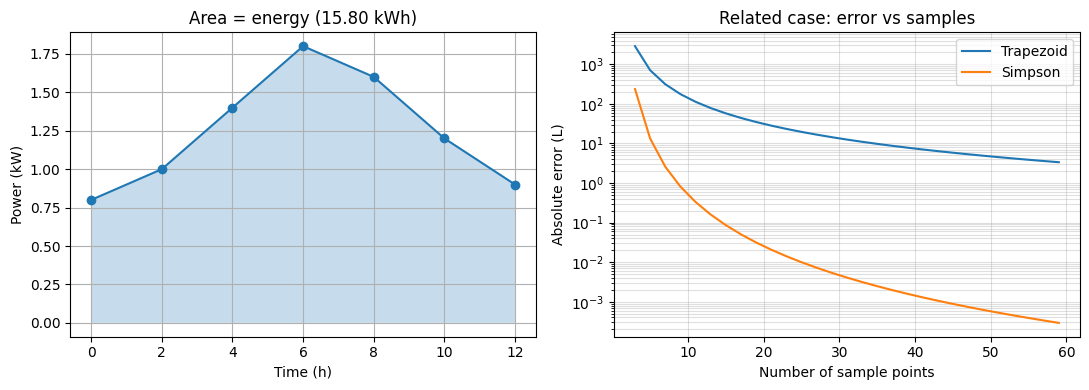

In [62]:
print("\n=== PART 3: Related case - water flow Q(t) = 5 + 3 sin(pi t / 6) L/s, t in [0,12] h -> exact volume known ===")
# t in hours; Q in litres/second. Volume in litres = integral Q dt * 3600
Q = lambda t: 5 + 3*np.sin(np.pi*t/6)
exact_L = (5*12 + 3*(6/np.pi)*(1 - np.cos(2*np.pi))) * 3600  # sin term integrates to 0 over a full period
quad_val, quad_err = quad(Q, 0, 12)
print(f"Exact volume = {exact_L:,.0f} L | quad: {quad_val*3600:,.0f} L (error est {quad_err:.1e})")
exact_part = (5*4 + 3*(6/np.pi)*(1 - np.cos(np.pi*4/6))) * 3600   # exact volume over [0, 4] h
print(f"Exact volume over the first 4 h = {exact_part:,.1f} L")
print("(Over the full 12 h the sine term is a whole period, so even the trapezoid rule is exact - see note in docs.)")
for n in (3, 5, 9, 25, 101):
    t = np.linspace(0, 4, n); q = Q(t)
    trap = np.trapezoid(q, t)*3600; sim = simpson(q, x=t)*3600
    print(f"n={n:3d} points on [0,4]: trapezoid err {abs(trap-exact_part):10.3f} L | Simpson err {abs(sim-exact_part):10.6f} L")

fig, ax = plt.subplots(1, 2, figsize=(11, 4))
ax[0].plot(time_hours, power_kw, "o-"); ax[0].fill_between(time_hours, power_kw, alpha=0.25)
ax[0].set_xlabel("Time (h)"); ax[0].set_ylabel("Power (kW)"); ax[0].set_title(f"Area = energy ({energy_simpson:.2f} kWh)"); ax[0].grid(True)
ns = np.arange(3, 60, 2); et = [abs(np.trapezoid(Q(np.linspace(0,4,n)), np.linspace(0,4,n))*3600 - exact_part) for n in ns]
es = [abs(simpson(Q(np.linspace(0,4,n)), x=np.linspace(0,4,n))*3600 - exact_part) + 1e-12 for n in ns]
ax[1].semilogy(ns, et, label="Trapezoid"); ax[1].semilogy(ns, es, label="Simpson"); ax[1].set_xlabel("Number of sample points"); ax[1].set_ylabel("Absolute error (L)")
ax[1].set_title("Related case: error vs samples"); ax[1].legend(); ax[1].grid(True, which="both", alpha=0.4)
plt.tight_layout(); plt.show()

---
## Task 17 – Ordinary Differential Equations: Euler Method

Simulate cooling of a hot object step by step and compare with the exact solution.

In [63]:
import numpy as np
import matplotlib.pyplot as plt

def euler(f, y0, t0, t_end, h):
    t = np.arange(t0, t_end + h/2, h); y = np.zeros_like(t); y[0] = y0
    for i in range(len(t) - 1):
        y[i + 1] = y[i] + h * f(t[i], y[i])
    return t, y

In [64]:
print("=== PART 0: Worked example dy/dt = y, y(0)=1, h=0.1 ===")
t, y = euler(lambda t, y: y, 1.0, 0, 0.2, 0.1)
print("y1, y2 =", np.round(y[1:], 4), "(exact e^0.1, e^0.2 =", round(np.exp(0.1), 4), round(np.exp(0.2), 4), ")")

T_ambient, T_initial = 25.0, 90.0
def cooling(k):
    return lambda t, T: -k * (T - T_ambient)
exact_fn = lambda t, k: T_ambient + (T_initial - T_ambient) * np.exp(-k * t)

=== PART 0: Worked example dy/dt = y, y(0)=1, h=0.1 ===
y1, y2 = [1.1  1.21] (exact e^0.1, e^0.2 = 1.1052 1.2214 )


**Part 1 – Original program** (from the brief, with extra checks).

In [65]:
print("\n=== PART 1: Original - cooling, k=0.12, h=1 min, 30 min ===")
time, temperature = euler(cooling(0.12), T_initial, 0, 30, 1.0)
exact = exact_fn(time, 0.12)
print(f"Euler temperature after 30 min: {temperature[-1]:.2f} C")
print(f"Exact temperature after 30 min: {exact[-1]:.2f} C")
print(f"Final absolute error: {abs(temperature[-1]-exact[-1]):.4f} C")


=== PART 1: Original - cooling, k=0.12, h=1 min, 30 min ===
Euler temperature after 30 min: 26.40 C
Exact temperature after 30 min: 26.78 C
Final absolute error: 0.3720 C


**Part 2 – Changed input:** one or more parameters are changed to see how the result responds.

In [66]:
print("\n=== PART 2: Changed input - step size h and rate k ===")
for h in (5.0, 2.0, 1.0, 0.5, 0.1, 0.01):
    t_, y_ = euler(cooling(0.12), T_initial, 0, 30, h)
    print(f"h={h:5.2f} min: T(30)={y_[-1]:.4f} C | error {abs(y_[-1]-exact_fn(30, 0.12)):.5f} C")
t_, y_ = euler(cooling(0.12), T_initial, 0, 30, 20.0)
print("h=20 (h*k=2.4 > 2): oscillating/unstable ->", np.round(y_, 2))
t_, y_ = euler(cooling(0.30), T_initial, 0, 30, 1.0)
print(f"k=0.30 (faster cooling), h=1: T(30)={y_[-1]:.3f} C vs exact {exact_fn(30, 0.30):.3f} C")


=== PART 2: Changed input - step size h and rate k ===
h= 5.00 min: T(30)=25.2662 C | error 1.50980 C
h= 2.00 min: T(30)=26.0595 C | error 0.71650 C
h= 1.00 min: T(30)=26.4041 C | error 0.37196 C
h= 0.50 min: T(30)=26.5870 C | error 0.18901 C
h= 0.10 min: T(30)=26.7378 C | error 0.03825 C
h= 0.01 min: T(30)=26.7722 C | error 0.00384 C
h=20 (h*k=2.4 > 2): oscillating/unstable -> [ 90. -66.]
k=0.30 (faster cooling), h=1: T(30)=25.001 C vs exact 25.008 C


**Part 3 – Related real-world case:** the program adapted to a different problem.


=== PART 3: Related case - logistic growth of a fish population (r=0.4/yr, K=1000, P0=50) ===
h=2.00 yr: P(10)=  600.75 | P(30)= 1000.00 | error at t=10:  141.087
h=1.00 yr: P(10)=  679.03 | P(30)=  999.98 | error at t=10:   62.814
h=0.25 yr: P(10)=  727.91 | P(30)=  999.92 | error at t=10:   13.931
Exact: P(10)=741.84, P(30)=999.88 -> approaches carrying capacity K=1000
Population reaches K/2=500 at t = 7.36 years (inflection point of the S-curve)


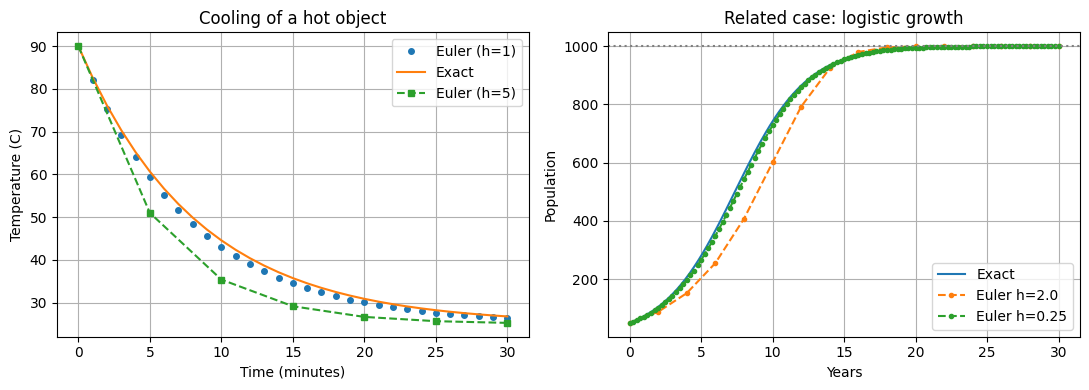

In [67]:
print("\n=== PART 3: Related case - logistic growth of a fish population (r=0.4/yr, K=1000, P0=50) ===")
r, K, P0 = 0.4, 1000.0, 50.0
logistic = lambda t, P: r * P * (1 - P / K)
exact_log = lambda t: K / (1 + (K - P0)/P0 * np.exp(-r * t))
for h in (2.0, 1.0, 0.25):
    t_, P_ = euler(logistic, P0, 0, 30, h)
    print(f"h={h:4.2f} yr: P(10)={P_[int(round(10/h))]:8.2f} | P(30)={P_[-1]:8.2f} | error at t=10: {abs(P_[int(round(10/h))]-exact_log(10)):8.3f}")
print(f"Exact: P(10)={exact_log(10):.2f}, P(30)={exact_log(30):.2f} -> approaches carrying capacity K={K:.0f}")
t_half = np.log((K - P0)/P0)/r
print(f"Population reaches K/2=500 at t = {t_half:.2f} years (inflection point of the S-curve)")

fig, ax = plt.subplots(1, 2, figsize=(11, 4))
ax[0].plot(time, temperature, "o", ms=4, label="Euler (h=1)"); ax[0].plot(time, exact, label="Exact")
t5, y5 = euler(cooling(0.12), T_initial, 0, 30, 5.0); ax[0].plot(t5, y5, "s--", ms=4, label="Euler (h=5)")
ax[0].set_xlabel("Time (minutes)"); ax[0].set_ylabel("Temperature (C)"); ax[0].set_title("Cooling of a hot object"); ax[0].legend(); ax[0].grid(True)
tt = np.linspace(0, 30, 300); ax[1].plot(tt, exact_log(tt), label="Exact")
for h in (2.0, 0.25):
    t_, P_ = euler(logistic, P0, 0, 30, h); ax[1].plot(t_, P_, "o--", ms=3, label=f"Euler h={h}")
ax[1].axhline(K, ls=":", c="grey"); ax[1].set_xlabel("Years"); ax[1].set_ylabel("Population"); ax[1].set_title("Related case: logistic growth"); ax[1].legend(); ax[1].grid(True)
plt.tight_layout(); plt.show()

---
## Task 18 – Numerical Solution of ODEs Using SciPy

Solve an RC charging circuit with `solve_ivp`; extended to an SIR epidemic.

In [68]:
import numpy as np
from scipy.integrate import solve_ivp
import matplotlib.pyplot as plt

def rc_solve(R, C, Vs=5.0, V0=0.0, t_end=5.0, rtol=1e-9, atol=1e-11, method="RK45"):
    f = lambda t, V: [(Vs - V[0]) / (R * C)]
    t_eval = np.linspace(0, t_end, 200)
    sol = solve_ivp(f, (0, t_end), [V0], t_eval=t_eval, rtol=rtol, atol=atol, method=method)
    exact = Vs * (1 - np.exp(-sol.t / (R * C))) + V0*np.exp(-sol.t/(R*C))
    return sol, exact

**Part 1 – Original program** (from the brief, with extra checks).

In [69]:
print("=== PART 1: Original - RC charging, R=1000, C=0.001 (tau = 1 s) ===")
solution, exact = rc_solve(1000.0, 0.001)
print("Solver success:", solution.success)
print(f"Capacitor voltage at 5 s: {solution.y[0, -1]:.4f} V")
print(f"Maximum error against exact solution: {np.max(np.abs(solution.y[0]-exact)):.3e} V")
print("Function evaluations:", solution.nfev)
print(f"Voltage at t = tau (1 s): {np.interp(1.0, solution.t, solution.y[0]):.4f} V (theory 63.2% of 5 V = {5*(1-np.exp(-1)):.4f})")

=== PART 1: Original - RC charging, R=1000, C=0.001 (tau = 1 s) ===
Solver success: True
Capacitor voltage at 5 s: 4.9663 V
Maximum error against exact solution: 9.282e-10 V
Function evaluations: 386
Voltage at t = tau (1 s): 3.1605 V (theory 63.2% of 5 V = 3.1606)


**Part 2 – Changed input:** one or more parameters are changed to see how the result responds.

In [70]:
print("\n=== PART 2: Changed input - C 0.001 -> 0.004 (tau = 4 s); then looser tolerance; then Radau solver ===")
s2, e2 = rc_solve(1000.0, 0.004)
print(f"V(5 s) = {s2.y[0,-1]:.4f} V (theory {5*(1-np.exp(-5/4)):.4f}); fraction of supply reached {s2.y[0,-1]/5:.1%}")
s3, e3 = rc_solve(1000.0, 0.001, rtol=1e-3, atol=1e-6)
print(f"Loose tolerance rtol=1e-3: max error {np.max(np.abs(s3.y[0]-e3)):.2e} V, nfev {s3.nfev} (was {solution.nfev})")
s4, e4 = rc_solve(1000.0, 0.001, method="Radau")
print(f"Stiff-capable solver Radau: max error {np.max(np.abs(s4.y[0]-e4)):.2e} V, nfev {s4.nfev}")


=== PART 2: Changed input - C 0.001 -> 0.004 (tau = 4 s); then looser tolerance; then Radau solver ===
V(5 s) = 3.5675 V (theory 3.5675); fraction of supply reached 71.3%
Loose tolerance rtol=1e-3: max error 6.64e-04 V, nfev 56 (was 386)
Stiff-capable solver Radau: max error 4.94e-10 V, nfev 1435


**Part 3 – Related real-world case:** the program adapted to a different problem.


=== PART 3: Related case - SIR epidemic, population 10,000, beta=0.35, gamma=0.10 ===
R0 = beta/gamma = 3.50
Peak infections: 3566 on day 31.8
Total ever infected (final R): 9660 (96.6%) | still susceptible: 340
Conservation check max |S+I+R-N|: 7.28e-12
With distancing beta=0.18 (R0=1.8): peak 1185 on day 80.4; final infected 7223 (72.2%)


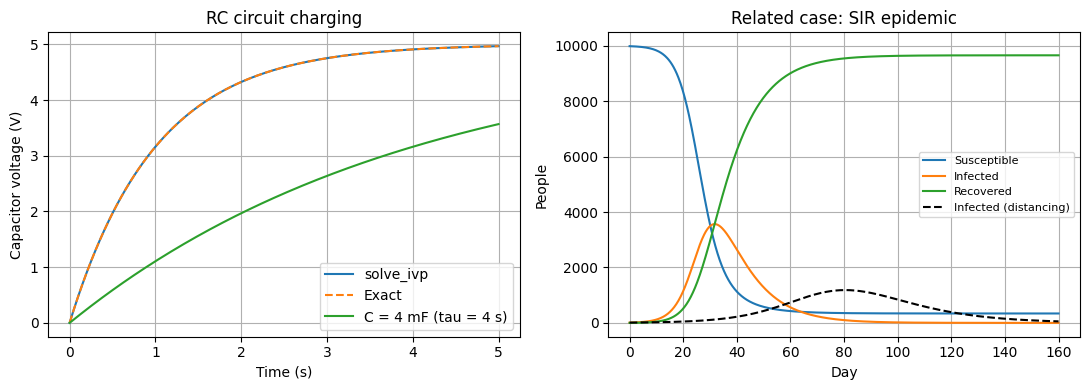

In [71]:
print("\n=== PART 3: Related case - SIR epidemic, population 10,000, beta=0.35, gamma=0.10 ===")
N, beta, gamma = 10_000.0, 0.35, 0.10
def sir(t, y, beta=beta):
    S, I, R = y
    return [-beta*S*I/N, beta*S*I/N - gamma*I, gamma*I]
t_eval = np.linspace(0, 160, 801)
s = solve_ivp(sir, (0, 160), [N-10, 10, 0], t_eval=t_eval, rtol=1e-8, atol=1e-10)
S, I, R = s.y
print(f"R0 = beta/gamma = {beta/gamma:.2f}")
print(f"Peak infections: {I.max():.0f} on day {s.t[I.argmax()]:.1f}")
print(f"Total ever infected (final R): {R[-1]:.0f} ({R[-1]/N:.1%}) | still susceptible: {S[-1]:.0f}")
print(f"Conservation check max |S+I+R-N|: {np.max(np.abs(S+I+R-N)):.2e}")
s_lock = solve_ivp(lambda t, y: sir(t, y, beta=0.18), (0, 160), [N-10, 10, 0], t_eval=t_eval, rtol=1e-8, atol=1e-10)
print(f"With distancing beta=0.18 (R0={0.18/gamma:.1f}): peak {s_lock.y[1].max():.0f} on day {s_lock.t[s_lock.y[1].argmax()]:.1f}; final infected {s_lock.y[2,-1]:.0f} ({s_lock.y[2,-1]/N:.1%})")

fig, ax = plt.subplots(1, 2, figsize=(11, 4))
ax[0].plot(solution.t, solution.y[0], label="solve_ivp"); ax[0].plot(solution.t, exact, "--", label="Exact")
ax[0].plot(s2.t, s2.y[0], label="C = 4 mF (tau = 4 s)"); ax[0].set_xlabel("Time (s)"); ax[0].set_ylabel("Capacitor voltage (V)")
ax[0].set_title("RC circuit charging"); ax[0].legend(); ax[0].grid(True)
ax[1].plot(s.t, S, label="Susceptible"); ax[1].plot(s.t, I, label="Infected"); ax[1].plot(s.t, R, label="Recovered")
ax[1].plot(s_lock.t, s_lock.y[1], "k--", label="Infected (distancing)")
ax[1].set_xlabel("Day"); ax[1].set_ylabel("People"); ax[1].set_title("Related case: SIR epidemic"); ax[1].legend(fontsize=8); ax[1].grid(True)
plt.tight_layout(); plt.show()

---
## Task 19 – Numerical Optimization

Choose the cheapest server mix that meets a capacity requirement using `minimize`.

In [72]:
import numpy as np
from scipy.optimize import minimize

def solve_cloud(cost_a=12, cost_b=18, cap_a=100, cap_b=170, required=1000):
    cost = lambda z: cost_a*z[0] + cost_b*z[1]
    cons = {"type": "ineq", "fun": lambda z: cap_a*z[0] + cap_b*z[1] - required}
    sol = minimize(cost, x0=[5, 3], method="SLSQP", bounds=[(0, None), (0, None)], constraints=cons)
    best = None
    for a in range(0, 40):
        for b in range(0, 40):
            if cap_a*a + cap_b*b >= required:
                c_ = cost_a*a + cost_b*b
                if best is None or c_ < best[0]:
                    best = (c_, a, b, cap_a*a + cap_b*b)
    return sol, best

In [73]:
print("=== PART 0: f(x) = (x-3)^2 + 2 ===")
r = minimize(lambda x: (x[0]-3)**2 + 2, x0=[0.0])
print("Minimum at x =", np.round(r.x, 6), "| value =", round(r.fun, 6))

=== PART 0: f(x) = (x-3)^2 + 2 ===
Minimum at x = [3.] | value = 2.0


**Part 1 – Original program** (from the brief, with extra checks).

In [74]:
print("\n=== PART 1: Original ===")
solution, best_integer = solve_cloud()
x, y = solution.x
print("Optimization success:", solution.success)
print(f"Type A allocation: {x:.3f}")
print(f"Type B allocation: {y:.3f}")
print(f"Total capacity: {100*x + 170*y:.2f}")
print(f"Minimum planning cost: {solution.fun:.2f}")
print("Best nearby integer solution (cost, A, B, capacity):", best_integer)
print(f"Cost per capacity unit: A = {12/100:.4f}, B = {18/170:.4f} -> B is cheaper per unit of capacity")


=== PART 1: Original ===
Optimization success: True
Type A allocation: 0.000
Type B allocation: 5.882
Total capacity: 1000.00
Minimum planning cost: 105.88
Best nearby integer solution (cost, A, B, capacity): (108, 0, 6, 1020)
Cost per capacity unit: A = 0.1200, B = 0.1059 -> B is cheaper per unit of capacity


**Part 2 – Changed input:** one or more parameters are changed to see how the result responds.

In [75]:
print("\n=== PART 2: Changed input - Type B cost 18 -> 24 and requirement 1000 -> 1500 ===")
s2, b2 = solve_cloud(cost_b=24)
print(f"cost_B=24: A={s2.x[0]:.3f}, B={s2.x[1]:.3f}, cost {s2.fun:.2f} | integer best {b2}  (cost per unit B = {24/170:.4f} > A {0.12:.4f})")
s3, b3 = solve_cloud(required=1500)
print(f"required=1500: A={s3.x[0]:.3f}, B={s3.x[1]:.3f}, cost {s3.fun:.2f} | integer best {b3}")


=== PART 2: Changed input - Type B cost 18 -> 24 and requirement 1000 -> 1500 ===
cost_B=24: A=10.000, B=0.000, cost 120.00 | integer best (120, 10, 0, 1000)  (cost per unit B = 0.1412 > A 0.1200)
required=1500: A=0.000, B=8.824, cost 158.82 | integer best (162, 0, 9, 1530)


**Part 3 – Related real-world case:** the program adapted to a different problem.

In [76]:
print("\n=== PART 3: Related case - maximise factory profit ===")
# x = tables, y = chairs; profit 40 and 30; machine hours 2x + y <= 100; labour x + y <= 80; x <= 40
neg_profit = lambda z: -(40*z[0] + 30*z[1])
cons = [
    {"type": "ineq", "fun": lambda z: 100 - (2*z[0] + z[1])},
    {"type": "ineq", "fun": lambda z: 80 - (z[0] + z[1])},
]
sol = minimize(neg_profit, x0=[10, 10], method="SLSQP", bounds=[(0, 40), (0, None)], constraints=cons)
x, y = sol.x
print("Success:", sol.success)
print(f"Tables = {x:.3f}, Chairs = {y:.3f}, Max profit = {-sol.fun:.2f}")
print(f"Machine hours used: {2*x+y:.2f}/100 | labour used: {x+y:.2f}/80 | tables limit: {x:.2f}/40")
print("Both machine and labour constraints are active (binding); the table-limit is slack.")
best = max(((40*a + 30*b, a, b) for a in range(0, 41) for b in range(0, 81) if 2*a + b <= 100 and a + b <= 80))
print("Integer check (profit, tables, chairs):", best)
sol2 = minimize(neg_profit, x0=[10, 10], method="SLSQP", bounds=[(0, 40), (0, None)],
                constraints=[{"type": "ineq", "fun": lambda z: 120 - (2*z[0] + z[1])}, cons[1]])
print(f"If machine hours rise 100 -> 120: tables {sol2.x[0]:.2f}, chairs {sol2.x[1]:.2f}, profit {-sol2.fun:.2f} (gain {-sol2.fun+sol.fun:.2f} for 20 extra hours)")


=== PART 3: Related case - maximise factory profit ===
Success: True
Tables = 20.000, Chairs = 60.000, Max profit = 2600.00
Machine hours used: 100.00/100 | labour used: 80.00/80 | tables limit: 20.00/40
Both machine and labour constraints are active (binding); the table-limit is slack.
Integer check (profit, tables, chairs): (2600, 20, 60)
If machine hours rise 100 -> 120: tables 40.00, chairs 40.00, profit 2800.00 (gain 200.00 for 20 extra hours)


---
## Task 20 – Random Numbers and Monte Carlo Methods

Estimate the probability that a server is overloaded by simulating random demand.

In [77]:
import numpy as np
from scipy.stats import norm
import matplotlib.pyplot as plt

In [78]:
print("=== PART 0: Estimate pi (7850 of 10000 -> 3.14 and a real run) ===")
rng = np.random.default_rng(42)
for n in (1_000, 100_000, 5_000_000):
    pts = rng.random((n, 2))
    inside = (pts**2).sum(axis=1) <= 1
    est = 4 * inside.mean()
    print(f"N={n:>9,}: pi ~ {est:.5f} | error {abs(est-np.pi):.5f}")

=== PART 0: Estimate pi (7850 of 10000 -> 3.14 and a real run) ===
N=    1,000: pi ~ 3.08400 | error 0.05759
N=  100,000: pi ~ 3.15012 | error 0.00853
N=5,000,000: pi ~ 3.14225 | error 0.00066


**Part 1 – Original program** (from the brief, with extra checks).

In [79]:
print("\n=== PART 1: Original - server overload ===")
rng = np.random.default_rng(42)
capacity, mean_demand, std_demand, N = 1000.0, 850.0, 120.0, 100_000
demand = rng.normal(mean_demand, std_demand, N)
overloaded = demand > capacity
overload_probability = overloaded.mean()
print(f"Estimated overload probability: {overload_probability:.4%}")
print(f"Number of overload cases: {overloaded.sum()} out of {N}")
exact = 1 - norm.cdf(capacity, mean_demand, std_demand)
se = np.sqrt(overload_probability*(1-overload_probability)/N)
print(f"Exact probability (normal CDF): {exact:.4%} | MC standard error: {se:.4%}")
print(f"95% interval: [{overload_probability-1.96*se:.4%}, {overload_probability+1.96*se:.4%}]")
running_probability = np.cumsum(overloaded) / np.arange(1, N + 1)


=== PART 1: Original - server overload ===
Estimated overload probability: 10.6160%
Number of overload cases: 10616 out of 100000
Exact probability (normal CDF): 10.5650% | MC standard error: 0.0974%
95% interval: [10.4251%, 10.8069%]


**Part 2 – Changed input:** one or more parameters are changed to see how the result responds.

In [80]:
print("\n=== PART 2: Changed input - capacity 1000 -> 1150 (rare event), and N = 1,000 ===")
for cap in (900, 1000, 1150):
    for n in (1_000, 100_000):
        d = np.random.default_rng(1).normal(850, 120, n)
        p_ = (d > cap).mean()
        print(f"capacity {cap}, N={n:>7,}: estimate {p_:.4%} | exact {1-norm.cdf(cap, 850, 120):.4%}")
print("Std demand 120 -> 200 at capacity 1000:", f"{(np.random.default_rng(1).normal(850, 200, 100_000) > 1000).mean():.4%}",
      f"(exact {1-norm.cdf(1000, 850, 200):.4%})")


=== PART 2: Changed input - capacity 1000 -> 1150 (rare event), and N = 1,000 ===
capacity 900, N=  1,000: estimate 31.7000% | exact 33.8461%
capacity 900, N=100,000: estimate 33.4720% | exact 33.8461%
capacity 1000, N=  1,000: estimate 8.7000% | exact 10.5650%
capacity 1000, N=100,000: estimate 10.3290% | exact 10.5650%
capacity 1150, N=  1,000: estimate 0.6000% | exact 0.6210%
capacity 1150, N=100,000: estimate 0.6080% | exact 0.6210%
Std demand 120 -> 200 at capacity 1000: 22.3660% (exact 22.6627%)


**Part 3 – Related real-world case:** the program adapted to a different problem.


=== PART 3: Related case - will a 3-task project finish within 30 days? ===
Mean total duration: 32.31 days | std 3.88
P(total > 30 days) = 70.6355%
Median 32.13 | 90th percentile 37.50 | 95th percentile 39.02 days
Sum of 'most likely' values = 28 days (ignores skew; mean is 32.31)
  deadline 26 days -> P(late) = 95.82%
  deadline 28 days -> P(late) = 86.46%
  deadline 30 days -> P(late) = 70.64%
  deadline 32 days -> P(late) = 51.25%
  deadline 35 days -> P(late) = 24.47%


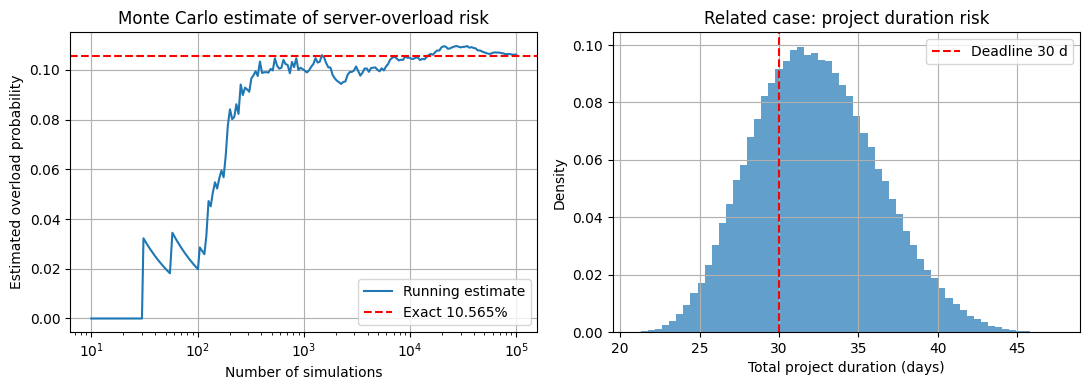

In [81]:
print("\n=== PART 3: Related case - will a 3-task project finish within 30 days? ===")
rng = np.random.default_rng(2026)
M = 200_000
# triangular(min, most likely, max) in days; tasks run in sequence
design = rng.triangular(5, 8, 14, M)
build = rng.triangular(10, 14, 24, M)
test = rng.triangular(4, 6, 12, M)
total = design + build + test
deadline = 30.0
print(f"Mean total duration: {total.mean():.2f} days | std {total.std():.2f}")
print(f"P(total > {deadline:.0f} days) = {(total > deadline).mean():.4%}")
print(f"Median {np.median(total):.2f} | 90th percentile {np.percentile(total, 90):.2f} | 95th percentile {np.percentile(total, 95):.2f} days")
print(f"Sum of 'most likely' values = {8+14+6} days (ignores skew; mean is {total.mean():.2f})")
for dl in (26, 28, 30, 32, 35):
    print(f"  deadline {dl} days -> P(late) = {(total > dl).mean():.2%}")

idx = np.unique(np.logspace(1, np.log10(N), 200).astype(int)) - 1
fig, ax = plt.subplots(1, 2, figsize=(11, 4))
ax[0].semilogx(idx + 1, running_probability[idx], label="Running estimate"); ax[0].axhline(exact, ls="--", c="r", label=f"Exact {exact:.3%}")
ax[0].set_xlabel("Number of simulations"); ax[0].set_ylabel("Estimated overload probability"); ax[0].set_title("Monte Carlo estimate of server-overload risk"); ax[0].legend(); ax[0].grid(True)
ax[1].hist(total, bins=60, density=True, alpha=0.7); ax[1].axvline(deadline, c="r", ls="--", label=f"Deadline {deadline:.0f} d")
ax[1].set_xlabel("Total project duration (days)"); ax[1].set_ylabel("Density"); ax[1].set_title("Related case: project duration risk"); ax[1].legend(); ax[1].grid(True)
plt.tight_layout(); plt.show()